# Business Case 1 - Segmenting Clients

This version is split into smaller notebook cells so the workflow is easier to follow.

**Notebook flow**
1. Setup and configuration  
2. Function definitions by topic  
3. Data loading and cleaning  
4. Model benchmarking and `k` choice  
5. Final segmentation  
6. Robustness checks  
7. Profile tables and exports  
8. Graphs, each in its own cell  
9. Summary


## 1) Imports

In [42]:
from __future__ import annotations

import math
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import Image, display


## 2) Configuration

In [43]:
# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# Path to the dataset
data_path = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1\Dataset1_BankClients.xlsx"
metadata_path = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1\BankClients_Metadata.xlsx"

# Directory where all outputs (models, plots, results) will be saved
OUTPUT_DIR = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1"
RANDOM_STATE = 42

# List of k values, number of clusters tested for the k-means algorithm
CANDIDATE_K = [4, 5, 6, 7, 8]
# Number of samples used for benchmarking (to reduce computation time)
BENCHMARK_SAMPLE_SIZE = 1200
# Number of samples used for silhouette score (to reduce computation time)
SILHOUETTE_SAMPLE_SIZE = 800

# Grid of values to test for DBSCAN (they correspond to the maximum radius of neighborhood)
DBSCAN_EPS_GRID = [0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26]
# Minimum number of points required to form a dense region in DBSCAN
DBSCAN_MIN_SAMPLES = 25

# List of categorical columns in the dataset
CATEGORICAL_COLS = ["Gender", "Job", "Area", "CitySize", "Investments"]

# Value mapping: introduces dictionaries to convert numeric codes into readable labels
VALUE_MAPS: Dict[str, Dict[int, str]] = {
    "Gender": {0: "Male", 1: "Female"},
    "Job": {
        1: "Unemployed",
        2: "Employee/Worker",
        3: "Manager/Executive",
        4: "Entrepreneur/Freelancer",
        5: "Retired",
    },
    "Area": {1: "North", 2: "Center", 3: "South/Islands"},
    "CitySize": {1: "Small town", 2: "Medium city", 3: "Large city"},
    "Investments": {
        1: "No investments",
        2: "Mostly lump sum",
        3: "Mostly capital accumulation",
    },
}

# Expected ranges for numerical variables
NUMERIC_BOUNDS = {
    "Age": (18, 100),
    "FamilySize": (1, 10),
    "Income": (0, 1),
    "Wealth": (0, 1),
    "Debt": (0, 1),
    "FinEdu": (0, 1),
    "ESG": (0, 1),
    "Digital": (0, 1),
    "BankFriend": (0, 1),
    "LifeStyle": (0, 1),
    "Luxury": (0, 1),
    "Saving": (0, 1),
}

# Each feature is assigned to a block (demographic, financial, behavioral)
FEATURE_BLOCKS = {
    "Age": "demographic",
    "Gender": "demographic",
    "Job": "demographic",
    "Area": "demographic",
    "CitySize": "demographic",
    "FamilySize": "demographic",
    "Income": "financial",
    "Wealth": "financial",
    "Debt": "financial",
    "Saving": "financial",
    "FinEdu": "behavioral",
    "ESG": "behavioral",
    "Digital": "behavioral",
    "BankFriend": "behavioral",
    "LifeStyle": "behavioral",
    "Luxury": "behavioral",
    "Investments": "behavioral",
}

# Definition of different feature weighting schemes used to influence clustering
# Each scheme assigns a relative importance to demographic, financial, and behavioral variables
# This directly impacts distance calculations between clients and therefore the resulting clusters
# It allows adapting the segmentation to different business objectives (e.g., financial analysis vs. behavioral segmentation)

WEIGHT_SCHEMES = {
    # All feature groups have equal importance
    "equal": {"demographic": 1.0, "financial": 1.0, "behavioral": 1.0},
    # Financial variables are emphasized
    "financial_focus": {"demographic": 0.9, "financial": 1.2, "behavioral": 1.0},
    # Behavioral variables are emphasized
    "behavioral_focus": {"demographic": 0.9, "financial": 1.0, "behavioral": 1.2},
}

# Create output directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3) Data structures

In [44]:
# -----------------------------------------------------------------------------
# DATA STRUCTURES
# -----------------------------------------------------------------------------

# Dataclass used to store the output of a K-Medoids clustering run
@dataclass
class KMedoidsResult:
    # Array containing the selected medoids
    medoids: np.ndarray

    # Cluster label assigned to each observation
    labels: np.ndarray

    # Total clustering cost (sum of distances to the assigned medoids)
    total_cost: float

    # Number of iterations performed before convergence
    n_iter: int


# Dataclass used to store the cleaned and prepared dataset
@dataclass
class PreparedData:
    # Final prepared dataset after preprocessing
    data: pd.DataFrame

    # Metadata associated with the dataset (feature descriptions, etc.)
    metadata: pd.DataFrame

    # List of numerical columns kept in the dataset
    numeric_cols: List[str]

    # List of categorical columns kept in the dataset
    categorical_cols: List[str]

    # Columns that have zero variance
    removed_zero_variance_cols: List[str]

    # Columns with very low variance
    near_zero_variance_cols: List[str]

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]

## 4) Cleaning functions

In [45]:
# -----------------------------------------------------------------------------
# CLEANING
# -----------------------------------------------------------------------------

# Detect different forms of missing values and replaces them with np.nan
def normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    tokens = {"", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"}
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].replace(list(tokens), np.nan)
    return out

# Detect whether a feature has near-zero variance
def detect_near_zero_variance(series: pd.Series) -> bool:
    s = series.dropna()

    # If the column is empty, it is considered useless and we return True 
    if s.empty:
        return True
        
    # If a column contains only one value, it is considered useless and we return True 
    counts = s.value_counts()
    if len(counts) == 1:
        return True

    # Compute the ratio between the most frequent and second most frequent values
    freq_ratio = counts.iloc[0] / max(counts.iloc[1], 1)
    
    # Compute the ratio between the number of different values and the total number of observations used to measure the diversity of values in this feature
    pct_unique = s.nunique() / len(s)
    return (freq_ratio >= 20) and (pct_unique <= 0.10)


def clean_and_audit_data(data: pd.DataFrame, metadata: pd.DataFrame) -> PreparedData:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())
    
    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial shape: {df.shape}")

    # Remove fully duplicated rows
    exact_dupes = int(df.duplicated().sum())
    if exact_dupes > 0:
        df = df.drop_duplicates().copy()
    audit_lines.append(f"Exact duplicate rows removed: {exact_dupes}")

    # Remove duplicated IDs, keeping only the first occurrence
    duplicate_ids = int(df["ID"].duplicated().sum())
    if duplicate_ids > 0:
        df = df.drop_duplicates(subset=["ID"], keep="first").copy()
    audit_lines.append(f"Duplicate IDs removed: {duplicate_ids}")
    
    # Delete the columns 'ID' that doesn't contains any usefull information for the clustering 
    df = df.drop(columns=['ID'])

    # Identify categorical columns
    # Identify numeric columns by excluding ID and categorical columns
    categorical_cols = CATEGORICAL_COLS.copy()
    numeric_cols = [c for c in df.columns if c not in categorical_cols]

    # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


    # Validate categorical codes against allowed values defined in VALUE_MAPS
    # All invalid values become: NaN
    audit_lines.append("Invalid categorical codes replaced with missing values:")
    for col in categorical_cols:
        allowed = set(VALUE_MAPS[col].keys())
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan
        audit_lines.append(f"  - {col}: {invalid_count}")

    # Limit numeric variables to the valid bounds defined in NUMERIC_BOUNDS
    # If a value is greater than the maximum allowed value, it takes the higher value
    # Conversely, if a value is less than the minimum allowed value, it takes the lower value
    audit_lines.append("Out-of-range numeric values clipped to allowed bounds:")
    for col, (lower, upper) in NUMERIC_BOUNDS.items():
        if col not in df.columns:
            continue
        before = df[col].copy()
        df[col] = df[col].clip(lower=lower, upper=upper)
        audit_lines.append(f"  - {col}: {int((before != df[col]).sum())}")

    # Record missing values before imputation
    audit_lines.append("Missing values before imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Impute missing numeric values with the median
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    # Impute missing categorical values with the most frquence value taken
    # If this value doesn't exist, it uses a fallback value defined from the allowed categories (VALUE_MAPS)
    # Finaly convert the entire column to ensure a consistent format usable by algorithms
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode(dropna=True)
            fallback = sorted(VALUE_MAPS[col].keys())[0]
            fill_value = int(mode_value.iloc[0]) if not mode_value.empty else fallback
            df[col] = df[col].fillna(fill_value)

        df[col] = df[col].astype(int)

    # Record missing values after imputation
    audit_lines.append("Missing values after imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Detect zero-variance and near-zero-variance features
    removed_zero_variance_cols: List[str] = []
    near_zero_variance_cols: List[str] = []

    # Iterate through the columns  
    # Save them that contained only a single value (and therefore having a variance of 0) in the list removed_zero_variance_cols
    # Save them that detecte as "near zero variance" in the list near_zero_variance_cols
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            removed_zero_variance_cols.append(col)
        elif detect_near_zero_variance(df[col]):
            near_zero_variance_cols.append(col)

    # Remove zero-variance columns
    if removed_zero_variance_cols:
        df = df.drop(columns=removed_zero_variance_cols).copy()

    audit_lines.append(
        "Zero-variance columns removed: "
        + (", ".join(removed_zero_variance_cols) if removed_zero_variance_cols else "none")
    )
    audit_lines.append(
        "Near-zero-variance columns flagged: "
        + (", ".join(near_zero_variance_cols) if near_zero_variance_cols else "none")
    )

    # Update column lists after removing zero-variance columns
    categorical_cols = [c for c in categorical_cols if c not in removed_zero_variance_cols]
    numeric_cols = [c for c in numeric_cols if c not in removed_zero_variance_cols]

    # Compute absolute correlation matrix for numeric features
    if numeric_cols:
        corr = df[numeric_cols].corr().abs()
        high_corr = []

        for i in range(len(corr.columns)):
            for j in range(i + 1, len(corr.columns)):
                if corr.iloc[i, j] >= 0.85:
                    high_corr.append((corr.index[i], corr.columns[j], float(corr.iloc[i, j])))

        if high_corr:
            audit_lines.append("High-correlation numeric pairs flagged (not auto-removed):")
            for a, b, r in high_corr:
                audit_lines.append(f"  - {a} vs {b}: {r:.3f}")
        else:
            audit_lines.append("High-correlation numeric pairs flagged: none above 0.85")
    else:
        audit_lines.append("High-correlation numeric pairs flagged: no numeric columns available")

    audit_lines.append(f"Final shape after cleaning: {df.shape}")

    return PreparedData(
        data=df,
        metadata=metadata,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        removed_zero_variance_cols=removed_zero_variance_cols,
        near_zero_variance_cols=near_zero_variance_cols,
        audit_lines=audit_lines,
    )

## 5) Normalize numerical variables

In [46]:
# Standardize the numerical data using min-max scaling (compatible with Gower distance)
def standardize_numeric_minmax(df: pd.DataFrame, numeric_cols: List[str]) -> pd.DataFrame:

    df = df.copy()

    if numeric_cols:
        x_num = df[numeric_cols].astype(float).copy()
        # replace (0,1) to avoid tto devide by 0 
        ranges = (x_num.max() - x_num.min()).replace(0, 1)
        df[numeric_cols] = (x_num - x_num.min()) / ranges

    return df

## 6) Encoding categorical variables

In [47]:
# Create a OneHotEncoder to transform categorical variables to standardize them (not used for Gower)
def encode_categorical_features(df: pd.DataFrame, categorical_cols: List[str]) -> Tuple[pd.DataFrame, List[str]]:

    df = df.copy()

    if not categorical_cols:
        return df, categorical_cols

    # The parameter name for disabling sparse output changed ("sparse" was replaced by "sparse_output")
    # so we try the new version first and fall back to the old one if needed
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
        
    cat_encoded = encoder.fit_transform(df[categorical_cols])

    cat_col_names = encoder.get_feature_names_out(categorical_cols).tolist()
    df_cat_encoded = pd.DataFrame(cat_encoded, columns=cat_col_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_cat_encoded], axis=1)

    return df, cat_col_names

## 5) Load files and clean the dataset

In [48]:
# Load the main dataset and its associated metadata from Excel files
data = pd.read_excel(data_path)
metadata = pd.read_excel(metadata_path)

# data.drop(columns=['ID'])

prepared = clean_and_audit_data(data, metadata)

# Clean the dataset and generate audit information (e.g., removed columns, anomalies)
df_clean = prepared.data.copy()
numeric_cols = prepared.numeric_cols
categorical_cols = prepared.categorical_cols

df_gower = standardize_numeric_minmax(df_clean, numeric_cols)

df_standardized = standardize_numeric_minmax(df_clean, numeric_cols)
df_standardized, categorical_cols_encoded = encode_categorical_features(df_standardized, categorical_cols)

# Display basic information about the cleaned dataset
print(f"Rows after cleaning: {df_clean.shape[0]}")
print(f"Columns after cleaning: {df_clean.shape[1]}")

print(f"Rows in df_gower: {df_gower.shape[0]}")
print(f"Columns in df_gower: {df_gower.shape[1]}")

print(f"Rows in df_standardized: {df_standardized.shape[0]}")
print(f"Columns in df_standardized: {df_standardized.shape[1]}")

# Print audit log detailing preprocessing steps and data quality checks
for line in prepared.audit_lines:
    print("-", line)

# Display previews for comparison
display(data.head(9))
display(df_gower.head(9))
display(df_standardized.head(9))

Rows after cleaning: 5000
Columns after cleaning: 17
Rows in df_gower: 5000
Columns in df_gower: 17
Rows in df_standardized: 5000
Columns in df_standardized: 28
- DATA AUDIT
- ================================================================================
- Initial shape: (5000, 18)
- Exact duplicate rows removed: 0
- Duplicate IDs removed: 0
- Invalid categorical codes replaced with missing values:
-   - Gender: 0
-   - Job: 0
-   - Area: 0
-   - CitySize: 0
-   - Investments: 0
- Out-of-range numeric values clipped to allowed bounds:
-   - Age: 0
-   - FamilySize: 0
-   - Income: 0
-   - Wealth: 0
-   - Debt: 0
-   - FinEdu: 0
-   - ESG: 0
-   - Digital: 0
-   - BankFriend: 0
-   - LifeStyle: 0
-   - Luxury: 0
-   - Saving: 0
- Missing values before imputation:
-   - Age: 0
-   - Gender: 0
-   - Job: 0
-   - Area: 0
-   - CitySize: 0
-   - FamilySize: 0
-   - Income: 0
-   - Wealth: 0
-   - Debt: 0
-   - FinEdu: 0
-   - ESG: 0
-   - Digital: 0
-   - BankFriend: 0
-   - LifeStyle: 0


,ID,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,1,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,2,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,3,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,4,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,5,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2
5,6,81,0,2,1,3,4,0.461680,0.380243,0.490727,0.212120,0.422748,0.346738,0.364808,0.307310,0.500849,0.473036,3
6,7,20,1,1,1,3,3,0.654672,0.539156,0.086449,0.176028,0.220582,0.682363,0.542119,0.854401,0.736487,0.427275,1
7,8,90,1,3,1,1,3,0.467880,0.390456,0.515146,0.565612,0.431132,0.480668,0.620122,0.226242,0.139618,0.749447,2
8,9,41,1,3,1,2,1,0.387016,0.396111,0.478332,0.455602,0.571740,0.456114,0.281756,0.297446,0.342948,0.309757,2


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,0.065789,1,1,2,2,0.6,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,0.901051,0.293334,1
1,0.368421,1,2,2,3,0.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,0.917477,0.850925,3
2,0.250000,0,2,1,2,0.2,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,0.768338,0.521778,3
3,0.631579,0,2,1,2,0.4,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,0.519331,0.715921,2
4,0.184211,0,2,1,3,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,0.614119,0.637907,2
5,0.815789,0,2,1,3,0.6,0.469664,0.381925,0.502325,0.220379,0.400687,0.356808,0.283905,0.309700,0.502904,0.489926,3
6,0.013158,1,1,1,3,0.4,0.665994,0.541541,0.088492,0.182882,0.186914,0.702180,0.492252,0.861045,0.739508,0.442531,1
7,0.934211,1,3,1,1,0.4,0.475972,0.392183,0.527321,0.587634,0.409553,0.494627,0.583909,0.228002,0.140190,0.776207,2
8,0.289474,1,3,1,2,0.0,0.393709,0.397862,0.489637,0.473340,0.558234,0.469361,0.186315,0.299759,0.344355,0.320817,2


,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,0.065789,0.6,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.368421,0.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.250000,0.2,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.631579,0.4,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.184211,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,0.815789,0.6,0.469664,0.381925,0.502325,0.220379,0.400687,0.356808,0.283905,0.309700,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,0.013158,0.4,0.665994,0.541541,0.088492,0.182882,0.186914,0.702180,0.492252,0.861045,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.934211,0.4,0.475972,0.392183,0.527321,0.587634,0.409553,0.494627,0.583909,0.228002,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,0.289474,0.0,0.393709,0.397862,0.489637,0.473340,0.558234,0.469361,0.186315,0.299759,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 5) Distance functions

In [49]:
# -----------------------------------------------------------------------------
# DISTANCE
# -----------------------------------------------------------------------------

# Assign a weight to each characteristic based on its type (demographic, financial, behavioral) defined from one of the FEATURE_BLOCKS dictionaries
def feature_weights_from_scheme(columns: List[str], scheme: Dict[str, float]) -> np.ndarray:
    weights = []
    for col in columns:
        
        # If the column is known, its type is retrieved from the FEATURE_BLOCKS dictionary; otherwise, "behavioral" is applied to it
        block = FEATURE_BLOCKS.get(col, "behavioral")

        # Retrieve the weights defined in the WEIGHT_SCHEMES dictionary used
        weights.append(float(scheme.get(block, 1.0)))
    return np.asarray(weights, dtype=np.float32)

# Construct a distance matrix between all observations using Gower's distance to accommodate both numerical and categorical variables
def compute_gower_distance_matrix(df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str], block_weight_scheme: Optional[Dict[str, float]] = None) -> np.ndarray:
    n = len(df)
    D = np.zeros((n, n), dtype=np.float32)

    # If no weighting scheme is applied, all variables have the same weight
    if block_weight_scheme is None:
        num_weights = np.ones(len(numeric_cols), dtype=np.float32)
        cat_weights = np.ones(len(categorical_cols), dtype=np.float32)
    else:
        num_weights = feature_weights_from_scheme(numeric_cols, block_weight_scheme)
        cat_weights = feature_weights_from_scheme(categorical_cols, block_weight_scheme)
        
    total_weight = float(num_weights.sum() + cat_weights.sum())

    # The weights are applied directly to the data, but to the distances
    # Therefore, numerical and categorical data are treated differently
    if numeric_cols:
        x_num = df[numeric_cols].astype(np.float32)
        for idx, col in enumerate(numeric_cols):
            values = x_num[col].to_numpy(dtype=np.float32)
            D += num_weights[idx] * np.abs(values[:, None] - values[None, :])

    if categorical_cols:
        for idx, col in enumerate(categorical_cols):
            values = df[col].astype(str).to_numpy()
            D += cat_weights[idx] * (values[:, None] != values[None, :]).astype(np.float32)

    D /= max(total_weight, 1.0)
    return D

## 6) K-Medoids functions

In [50]:
# -----------------------------------------------------------------------------
# K-MEDOIDS
# -----------------------------------------------------------------------------
def kmedoids_pp_init(distance_matrix: np.ndarray, k: int, random_state: int) -> np.ndarray:
    rng = np.random.default_rng(random_state)
    n = distance_matrix.shape[0]
    medoids = [int(rng.integers(n))]
    while len(medoids) < k:
        dist_to_nearest = np.min(distance_matrix[:, medoids], axis=1)
        probs = dist_to_nearest**2
        probs[medoids] = 0
        prob_sum = probs.sum()
        if prob_sum == 0:
            remaining = np.setdiff1d(np.arange(n), np.array(medoids))
            medoids.append(int(rng.choice(remaining)))
        else:
            medoids.append(int(rng.choice(n, p=probs / prob_sum)))
    return np.array(medoids, dtype=int)


def assign_points_to_medoids(distance_matrix: np.ndarray, medoids: np.ndarray) -> np.ndarray:
    return np.argmin(distance_matrix[:, medoids], axis=1)


def compute_total_cost(distance_matrix: np.ndarray, medoids: np.ndarray, labels: np.ndarray) -> float:
    return float(distance_matrix[np.arange(len(labels)), medoids[labels]].sum())


def update_medoids(distance_matrix: np.ndarray, labels: np.ndarray, medoids: np.ndarray) -> np.ndarray:
    updated = medoids.copy()
    n = distance_matrix.shape[0]
    for cluster_id in range(len(medoids)):
        members = np.where(labels == cluster_id)[0]
        if len(members) == 0:
            continue
        cluster_distances = distance_matrix[np.ix_(members, members)]
        local_costs = cluster_distances.sum(axis=1)
        updated[cluster_id] = int(members[np.argmin(local_costs)])

    if len(np.unique(updated)) < len(updated):
        missing = np.setdiff1d(np.arange(n), updated)
        dup_positions = []
        seen = set()
        for idx, val in enumerate(updated):
            if val in seen:
                dup_positions.append(idx)
            else:
                seen.add(val)
        for pos, replacement in zip(dup_positions, missing[: len(dup_positions)]):
            updated[pos] = int(replacement)
    return updated


def kmedoids(distance_matrix: np.ndarray, k: int, max_iter: int = 50, random_state: int = 42) -> KMedoidsResult:
    medoids = kmedoids_pp_init(distance_matrix, k, random_state)
    labels = assign_points_to_medoids(distance_matrix, medoids)
    current_cost = compute_total_cost(distance_matrix, medoids, labels)
    n_iter = 0
    for n_iter in range(1, max_iter + 1):
        new_medoids = update_medoids(distance_matrix, labels, medoids)
        new_labels = assign_points_to_medoids(distance_matrix, new_medoids)
        new_cost = compute_total_cost(distance_matrix, new_medoids, new_labels)
        if np.array_equal(new_medoids, medoids) and np.array_equal(new_labels, labels):
            medoids, labels, current_cost = new_medoids, new_labels, new_cost
            break
        medoids, labels, current_cost = new_medoids, new_labels, new_cost
    return KMedoidsResult(medoids=medoids, labels=labels, total_cost=current_cost, n_iter=n_iter)

## 7) Metrics + benchmarking functions

In [51]:
# -----------------------------------------------------------------------------
# METRICS + BENCHMARKING
# -----------------------------------------------------------------------------
def safe_internal_metrics(X_encoded: np.ndarray, labels: np.ndarray, distance_matrix: Optional[np.ndarray] = None) -> Dict[str, float]:
    if len(np.unique(labels)) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}

    try:
        if distance_matrix is not None:
            sil = float(
                silhouette_score(
                    distance_matrix,
                    labels,
                    metric="precomputed",
                    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(labels)),
                    random_state=RANDOM_STATE,
                )
            )
        else:
            sil = float(
                silhouette_score(
                    X_encoded,
                    labels,
                    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(labels)),
                    random_state=RANDOM_STATE,
                )
            )
    except Exception:
        sil = np.nan

    try:
        ch = float(calinski_harabasz_score(X_encoded, labels))
    except Exception:
        ch = np.nan

    try:
        db = float(davies_bouldin_score(X_encoded, labels))
    except Exception:
        db = np.nan

    return {"silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db}


def _normalize_series(s: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = s.astype(float)
    if s.isna().all():
        return pd.Series(np.zeros(len(s)), index=s.index)
    s_min, s_max = s.min(), s.max()
    if math.isclose(s_min, s_max):
        out = pd.Series(np.ones(len(s)), index=s.index)
    else:
        out = (s - s_min) / (s_max - s_min)
    return out if higher_is_better else 1 - out


def choose_k_with_overlay(kmed_df: pd.DataFrame) -> Tuple[int, pd.DataFrame, List[str]]:
    notes: List[str] = []
    ch_opt = int(kmed_df.loc[kmed_df["calinski_harabasz"].idxmax(), "k"])
    db_opt = int(kmed_df.loc[kmed_df["davies_bouldin"].idxmin(), "k"])
    sil_opt = int(kmed_df.loc[kmed_df["silhouette"].idxmax(), "k"])
    vote_k = int(np.median([ch_opt, db_opt, sil_opt]))

    ranked = kmed_df.copy()
    ranked["sil_n"] = _normalize_series(ranked["silhouette"], True)
    ranked["ch_n"] = _normalize_series(ranked["calinski_harabasz"], True)
    ranked["db_n"] = _normalize_series(ranked["davies_bouldin"], False)
    ranked["cost_n"] = _normalize_series(ranked["total_cost"], False)
    ranked["minshare_n"] = _normalize_series(ranked["min_cluster_share"], True)
    ranked["composite_score"] = (
        0.35 * ranked["sil_n"]
        + 0.25 * ranked["ch_n"]
        + 0.15 * ranked["db_n"]
        + 0.15 * ranked["cost_n"]
        + 0.10 * ranked["minshare_n"]
    )
    ranked = ranked.sort_values(["composite_score", "silhouette"], ascending=[False, False]).reset_index(drop=True)

    top_composite_k = int(ranked.loc[0, "k"])
    notes.append(f"Metric vote suggests k={vote_k} (CH={ch_opt}, DB={db_opt}, Silhouette={sil_opt}).")
    notes.append(f"Best composite-score candidate is k={top_composite_k}.")

    chosen_k = top_composite_k
    usable = ranked[(ranked["k"].between(5, 7)) & (ranked["min_cluster_share"] >= 0.08)].copy()
    if not usable.empty:
        best_all = float(ranked["composite_score"].max())
        usable_close = usable[usable["composite_score"] >= best_all - 0.03].copy()
        if not usable_close.empty:
            chosen_k = int(usable_close.sort_values(["composite_score", "silhouette"], ascending=[False, False]).iloc[0]["k"])
            notes.append("Qualitative overlay applied: chose a business-usable k in the 5-7 range with no tiny clusters.")
        else:
            notes.append("Qualitative overlay checked but top candidate was already clearly better.")
    else:
        notes.append("No 5-7 cluster solution met the minimum cluster-share constraint.")

    return chosen_k, ranked, notes


def benchmark_models(
    df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int, List[str], np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_n = min(BENCHMARK_SAMPLE_SIZE, len(df))
    sample_index = np.sort(rng.choice(len(df), size=sample_n, replace=False))
    sample_df = df.iloc[sample_index].reset_index(drop=True)

    X_sample = df_processed
    D_sample = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])

    rows = []
    for k in CANDIDATE_K:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = km.fit_predict(X_sample)
        metrics = safe_internal_metrics(X_sample, labels)
        rows.append({
            "method": "kmeans_encoded",
            "k": k,
            "total_cost": float(km.inertia_),
            "min_cluster_share": float(pd.Series(labels).value_counts(normalize=True).min()),
            **metrics,
            "notes": "Useful benchmark, but less natural for mixed data.",
        })

    for k in CANDIDATE_K:
        ag = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
        labels = ag.fit_predict(D_sample)
        metrics = safe_internal_metrics(X_sample, labels, D_sample)
        rows.append({
            "method": "agglomerative_gower",
            "k": k,
            "total_cost": np.nan,
            "min_cluster_share": float(pd.Series(labels).value_counts(normalize=True).min()),
            **metrics,
            "notes": "Useful mixed-data alternative; hierarchy is informative.",
        })

    for k in CANDIDATE_K:
        result = kmedoids(D_sample, k=k, max_iter=50, random_state=RANDOM_STATE)
        metrics = safe_internal_metrics(X_sample, result.labels, D_sample)
        rows.append({
            "method": "kmedoids_gower",
            "k": k,
            "total_cost": float(result.total_cost),
            "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
            **metrics,
            "notes": "Best fit for mixed data and easiest to explain through real medoids.",
        })

    benchmark_df = pd.DataFrame(rows)

    dbscan_rows = []
    for eps in DBSCAN_EPS_GRID:
        db = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="precomputed")
        labels = db.fit_predict(D_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_share = float(np.mean(labels == -1))
        sil = np.nan
        if n_clusters >= 2 and noise_share < 0.40:
            keep = labels != -1
            try:
                sil = float(
                    silhouette_score(
                        D_sample[np.ix_(keep, keep)],
                        labels[keep],
                        metric="precomputed",
                        sample_size=min(SILHOUETTE_SAMPLE_SIZE, int(keep.sum())),
                        random_state=RANDOM_STATE,
                    )
                )
            except Exception:
                pass
        dbscan_rows.append({
            "method": "dbscan_gower",
            "eps": eps,
            "min_samples": DBSCAN_MIN_SAMPLES,
            "n_clusters": n_clusters,
            "noise_share": noise_share,
            "silhouette_non_noise": sil,
        })
    dbscan_df = pd.DataFrame(dbscan_rows)

    nn = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES, metric="precomputed")
    nn.fit(D_sample)
    distances, _ = nn.kneighbors(D_sample)
    knn_curve_df = pd.DataFrame({
        "rank": np.arange(1, len(D_sample) + 1),
        "distance_to_kth_neighbor": np.sort(distances[:, -1]),
    })

    kmed_df = benchmark_df[benchmark_df["method"] == "kmedoids_gower"].copy().reset_index(drop=True)
    chosen_k, _, selection_notes = choose_k_with_overlay(kmed_df)

    return benchmark_df, dbscan_df, knn_curve_df, chosen_k, selection_notes, sample_index, X_sample, D_sample

## 8) Robustness functions

In [83]:
# -----------------------------------------------------------------------------
# ROBUSTNESS
# -----------------------------------------------------------------------------
def cluster_stability_check(
    sample_df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
    chosen_k: int,
    n_runs: int = 6,
) -> pd.DataFrame:
    D = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])
    reference = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE)
    rows = []
    for run in range(1, n_runs + 1):
        result = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE + run)
        rows.append({
            "run": run,
            "ari_vs_reference": float(adjusted_rand_score(reference.labels, result.labels)),
            "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
            "total_cost": float(result.total_cost),
        })
    return pd.DataFrame(rows)


def weighted_sensitivity_check(
    sample_df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
    chosen_k: int,
    reference_labels: np.ndarray,
    X_sample: np.ndarray,
) -> pd.DataFrame:
    rows = []
    for scheme_name, scheme in WEIGHT_SCHEMES.items():
        D = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, scheme)
        result = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE)
        metrics = safe_internal_metrics(X_sample, result.labels, D)
        ari = np.nan if scheme_name == "equal" else float(adjusted_rand_score(reference_labels, result.labels))
        rows.append({
            "scheme": scheme_name,
            "demographic_weight": scheme["demographic"],
            "financial_weight": scheme["financial"],
            "behavioral_weight": scheme["behavioral"],
            "ari_vs_equal_gower": ari,
            "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
            "total_cost": float(result.total_cost),
            **metrics,
        })
    return pd.DataFrame(rows)

## 9) Profiling functions

In [84]:
# -----------------------------------------------------------------------------
# PROFILING
# -----------------------------------------------------------------------------
def mode_with_share(series: pd.Series) -> Tuple[int, float]:
    vc = series.value_counts(normalize=True, dropna=False)
    return int(vc.index[0]), float(vc.iloc[0])


def generate_persona_name(profile: pd.Series) -> str:
    age = profile["Age_mean"]
    wealth_delta = profile["Wealth_delta_vs_overall"]
    digital_delta = profile["Digital_delta_vs_overall"]
    family_delta = profile["FamilySize_delta_vs_overall"]
    gender_mode = profile["Gender_mode"]
    area_mode = profile["Area_mode"]
    city_mode = profile["CitySize_mode"]
    job_mode = profile["Job_mode"]
    inv_mode = profile["Investments_mode"]

    if age >= 75:
        return "Very Senior Conservative Retirees"
    if job_mode == "Retired" or (age >= 66 and digital_delta < -0.10):
        return "Late-Career Conservative Households"
    if inv_mode == "No investments" and age >= 65:
        return "Late-Career / Pre-Retirement Non-Investors"
    if wealth_delta > 0.12 and digital_delta > 0.12 and city_mode == "Large city":
        return "Affluent Digital Urban Professionals"
    if gender_mode == "Female" and wealth_delta > 0.00 and digital_delta > 0.05:
        return "Affluent Practical Women"
    if family_delta > 0.40:
        return "Mature Mainstream Families"
    if area_mode == "South/Islands" and city_mode == "Small town":
        return "Traditional Southern Households"
    return "Balanced Everyday Retail Clients"


def ensure_unique_persona_names(profiles: pd.DataFrame) -> pd.DataFrame:
    profiles = profiles.copy()
    counts = profiles["Persona"].value_counts()
    dupes = counts[counts > 1].index.tolist()
    for dup_name in dupes:
        idxs = profiles.index[profiles["Persona"] == dup_name].tolist()
        for idx in idxs:
            row = profiles.loc[idx]
            suffix = []
            if row["Investments_mode"] == "No investments":
                suffix.append("Non-Investors")
            elif row["Investments_mode"] == "Mostly capital accumulation":
                suffix.append("Investors")
            if row["Gender_mode"] == "Female":
                suffix.append("Women")
            elif row["Gender_mode"] == "Male":
                suffix.append("Men")
            if row["Area_mode"] == "South/Islands":
                suffix.append("Southern")
            elif row["CitySize_mode"] == "Large city":
                suffix.append("Urban")
            elif row["CitySize_mode"] == "Small town":
                suffix.append("Small-Town")
            if not suffix:
                suffix.append(f"C{int(row['Cluster'])}")
            profiles.loc[idx, "Persona"] = dup_name + " - " + " ".join(suffix[:2])
    return profiles


def derive_business_recommendation(profile: pd.Series) -> Dict[str, str]:
    age = profile["Age_mean"]
    wealth = profile["Wealth_mean"]
    debt = profile["Debt_mean"]
    finedu = profile["FinEdu_mean"]
    digital = profile["Digital_mean"]
    saving = profile["Saving_mean"]
    family = profile["FamilySize_mean"]
    investments_mode = profile["Investments_mode"]

    if age >= 75 or digital < 0.35:
        channel = "Branch + call center; simple, high-trust communication"
    elif digital >= 0.65:
        channel = "Digital-first servicing with app nudges and remote advisory"
    else:
        channel = "Hybrid servicing: digital for routine tasks, advisor for key moments"

    product_focus = []
    if wealth >= 0.65:
        product_focus.append("advisory / premium wealth management")
    if investments_mode == "No investments" or finedu < 0.45:
        product_focus.append("simple savings plans and guided investing onboarding")
    if family >= 3:
        product_focus.append("family protection, education savings, home-related offers")
    if age >= 68:
        product_focus.append("capital preservation, income protection, succession planning")
    if saving >= 0.58:
        product_focus.append("term deposits and goal-based saving products")
    if debt >= 0.52:
        product_focus.append("credit monitoring and debt-aware financial planning")
    if not product_focus:
        product_focus.append("core banking, savings, and basic investment bundles")

    if wealth >= 0.65 and digital >= 0.65:
        message = "Convenience, premium experience, fast digital access, personalized investment ideas"
    elif age >= 68:
        message = "Trust, safety, capital protection, clarity, and human support"
    elif family >= 3:
        message = "Security, family goals, practical value, and long-term planning"
    else:
        message = "Straightforward everyday banking with relevant cross-sell opportunities"

    if investments_mode == "No investments":
        next_best_action = "Launch a low-friction investing education journey and starter portfolio offer"
    elif wealth >= 0.65:
        next_best_action = "Offer portfolio review, premium service tier, and personalized advisory"
    elif family >= 3:
        next_best_action = "Bundle family protection, emergency savings, and home-related offers"
    else:
        next_best_action = "Use CRM triggers for life events and digital engagement campaigns"

    risk_note = (
        "Avoid complex communication; keep suitability and explainability high"
        if finedu < 0.45 or age >= 75
        else "Suitable for more targeted and differentiated communication"
    )

    return {
        "ServiceModel": channel,
        "ProductFocus": "; ".join(product_focus),
        "CommunicationAngle": message,
        "NextBestAction": next_best_action,
        "ComplianceOrConductNote": risk_note,
    }


def build_cluster_profiles(segmented_df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str]) -> pd.DataFrame:
    overall_means = segmented_df[numeric_cols].mean()
    total_n = len(segmented_df)
    rows = []
    for cluster_id, group in segmented_df.groupby("Cluster"):
        row = {"Cluster": int(cluster_id), "Count": int(len(group)), "Pct": float(len(group) / total_n)}
        for col in numeric_cols:
            mean_val = float(group[col].mean())
            row[f"{col}_mean"] = mean_val
            row[f"{col}_delta_vs_overall"] = float(mean_val - overall_means[col])
        for col in categorical_cols:
            code, share = mode_with_share(group[col])
            row[f"{col}_mode_code"] = code
            row[f"{col}_mode"] = VALUE_MAPS[col].get(code, str(code))
            row[f"{col}_mode_share"] = share
        rows.append(row)
    profiles = pd.DataFrame(rows).sort_values("Cluster").reset_index(drop=True)
    profiles["Persona"] = profiles.apply(generate_persona_name, axis=1)
    profiles = ensure_unique_persona_names(profiles)

    recs = profiles.apply(derive_business_recommendation, axis=1)
    for key in ["ServiceModel", "ProductFocus", "CommunicationAngle", "NextBestAction", "ComplianceOrConductNote"]:
        profiles[key] = recs.apply(lambda d: d[key])
    return profiles


def medoid_rows(segmented_df: pd.DataFrame, medoid_indices: np.ndarray, profiles: pd.DataFrame) -> pd.DataFrame:
    medoids = segmented_df.iloc[medoid_indices].copy().reset_index(drop=True)
    if "Cluster" in medoids.columns:
        medoids = medoids.drop(columns=["Cluster"])
    if "Persona" in medoids.columns:
        medoids = medoids.drop(columns=["Persona"])
    medoids.insert(0, "Cluster", range(len(medoid_indices)))
    medoids = medoids.merge(profiles[["Cluster", "Persona"]], on="Cluster", how="left")
    return medoids


def strongest_numeric_differences(profile_row: pd.Series, numeric_cols: List[str], top_n: int = 5) -> List[Tuple[str, float, float]]:
    deltas = []
    for col in numeric_cols:
        deltas.append((col, float(profile_row[f"{col}_mean"]), float(profile_row[f"{col}_delta_vs_overall"])))
    return sorted(deltas, key=lambda x: abs(x[2]), reverse=True)[:top_n]

## 10) Optional persona refresh demo

In [85]:
# -----------------------------------------------------------------------------
# OPTIONAL PERSONA REFRESH DEMO
# -----------------------------------------------------------------------------
def bayesian_update_mean(prior_mean: float, prior_strength: float, observed_mean: float, observed_strength: float) -> float:
    return float((prior_strength * prior_mean + observed_strength * observed_mean) / (prior_strength + observed_strength))


def build_persona_refresh_demo(profiles: pd.DataFrame, traits: List[str]) -> pd.DataFrame:
    rows = []
    for _, row in profiles.iterrows():
        for trait in traits:
            prior = float(row[f"{trait}_mean"])
            observed = min(1.0, max(0.0, prior + 0.10))
            posterior = bayesian_update_mean(prior, 20, observed, 5)
            rows.append({
                "Persona": row["Persona"],
                "Trait": trait,
                "PriorMean": prior,
                "ObservedMeanDemo": observed,
                "PosteriorMeanDemo": posterior,
            })
    return pd.DataFrame(rows)

## 11) Plot helper functions

### Plot labeling note
All charts below use explicit axis labels. Where a real physical unit is not available, the label states that the axis is **dimensionless**, a **count**, or a **category**. For the feature heatmap, the x-axis contains mixed original feature units, so the color scale is shown after min-max normalization to 0-1.

In [86]:
# -----------------------------------------------------------------------------
# PLOTS
# -----------------------------------------------------------------------------
def save_cluster_size_plot(profiles: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(profiles["Persona"], profiles["Count"])
    ax.set_title("Final customer segment sizes")
    ax.set_xlabel("Customer segment / persona (category)")
    ax.set_ylabel("Number of clients (count)")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_kmeans_elbow_plot(benchmark_df: pd.DataFrame, out_path: str) -> None:
    km = benchmark_df[benchmark_df["method"] == "kmeans_encoded"].sort_values("k")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(km["k"], km["total_cost"], marker="o")
    ax.set_title("K-Means baseline - elbow plot")
    ax.set_xlabel("Number of clusters, k (count)")
    ax.set_ylabel("Within-cluster cost / inertia (unitless, encoded feature space)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_benchmark_silhouette_plot(benchmark_df: pd.DataFrame, out_path: str) -> None:
    plot_df = benchmark_df.dropna(subset=["silhouette"]).copy()
    plot_df["label"] = plot_df["method"] + " (k=" + plot_df["k"].astype(str) + ")"
    plot_df = plot_df.sort_values("silhouette", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(plot_df["label"], plot_df["silhouette"])
    ax.set_title("Benchmark comparison - silhouette scores")
    ax.set_xlabel("Silhouette score (dimensionless)")
    ax.set_ylabel("Model configuration (method and k)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_dbscan_knn_plot(knn_curve_df: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(knn_curve_df["rank"], knn_curve_df["distance_to_kth_neighbor"])
    ax.set_title(f"K-nearest-neighbor distance curve (k={DBSCAN_MIN_SAMPLES})")
    ax.set_xlabel("Sorted client observations (count)")
    ax.set_ylabel("Distance to k-th nearest neighbor (Gower distance, 0 to 1)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_pca_scatter(segmented_df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str], out_path: str) -> None:
    X = df_processed
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    xy = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(xy[:, 0], xy[:, 1], c=segmented_df["Cluster"], s=20, alpha=0.7)
    ax.set_title("2D PCA view of final clusters (visual aid only)")
    ax.set_xlabel("Principal component 1 score (unitless)")
    ax.set_ylabel("Principal component 2 score (unitless)")
    fig.colorbar(scatter, ax=ax, label="Cluster ID (category)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_profile_heatmap(profiles: pd.DataFrame, numeric_cols: List[str], out_path: str) -> None:
    values = profiles[[f"{col}_mean" for col in numeric_cols]].copy()
    values.index = profiles["Persona"]
    values.columns = numeric_cols
    normed = (values - values.min()) / (values.max() - values.min()).replace(0, 1)
    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(normed.to_numpy(), aspect="auto")
    ax.set_title("Relative feature intensity by segment")
    ax.set_xlabel("Numeric input features (mixed original units; normalized for comparison)")
    ax.set_ylabel("Customer segment / persona (category)")
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(normed.index)))
    ax.set_yticklabels(normed.index)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label="Relative intensity (min-max scaled, 0 to 1)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_final_silhouette_plot(distance_matrix: np.ndarray, labels: np.ndarray, out_path: str) -> None:
    sil_vals = silhouette_samples(distance_matrix, labels, metric="precomputed")
    fig, ax = plt.subplots(figsize=(10, 8))
    y_lower = 10
    for cluster_id in sorted(np.unique(labels)):
        csil = np.sort(sil_vals[labels == cluster_id])
        y_upper = y_lower + len(csil)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, csil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(csil), f"C{cluster_id}")
        y_lower = y_upper + 10
    ax.axvline(float(np.mean(sil_vals)), linestyle="--")
    ax.set_title("Silhouette plot for final segmentation (sample)")
    ax.set_xlabel("Silhouette score (dimensionless)")
    ax.set_ylabel("Client observations grouped by cluster (count)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_stability_plot(stability_df: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(stability_df["run"], stability_df["ari_vs_reference"], marker="o")
    ax.set_ylim(0, 1)
    ax.set_title("Cluster stability across repeated random seeds")
    ax.set_xlabel("Repeated clustering run (count)")
    ax.set_ylabel("ARI vs reference clustering (0 to 1, dimensionless)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_sensitivity_plot(sensitivity_df: pd.DataFrame, out_path: str) -> None:
    plot_df = sensitivity_df.copy()
    plot_df["ari_vs_equal_gower"] = plot_df["ari_vs_equal_gower"].fillna(1.0)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(plot_df["scheme"], plot_df["ari_vs_equal_gower"])
    ax.set_ylim(0, 1)
    ax.set_title("Sensitivity to alternative block-weight schemes")
    ax.set_xlabel("Feature-block weighting scheme (category)")
    ax.set_ylabel("ARI vs equal-weight Gower (0 to 1, dimensionless)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


## 12) Text export functions

In [87]:
# -----------------------------------------------------------------------------
# TEXT EXPORT
# -----------------------------------------------------------------------------
def write_executive_summary(
    out_path: str,
    audit_lines: List[str],
    selection_notes: List[str],
    stability_df: pd.DataFrame,
    sensitivity_df: pd.DataFrame,
    chosen_k: int,
    profiles: pd.DataFrame,
    numeric_cols: List[str],
) -> None:
    lines = []
    lines.append("# Client Segmentation Project - Plain-English Summary")
    lines.append("")
    lines.append("## 1) What we are doing")
    lines.append("We group bank clients into a small set of practical personas that can guide products, channels, and communication.")
    lines.append("")
    lines.append("## 2) Cleaning first")
    lines.append("The code checks duplicates, invalid codes, missing values, zero-variance columns, near-zero-variance columns, and anomalies before clustering.")
    lines.append("")
    lines.append("## 3) Why multiple methods")
    lines.append("Because the dataset mixes numerical and categorical features, one method alone is not enough for a serious business case.")
    lines.append("")
    lines.append("## 4) How k was chosen")
    lines.extend([f"- {x}" for x in selection_notes])
    lines.append("")
    lines.append("## 5) Robustness")
    lines.append(f"- Mean seed-stability ARI: {stability_df['ari_vs_reference'].mean():.3f}")
    if 'ari_vs_equal_gower' in sensitivity_df.columns:
        alt = sensitivity_df['ari_vs_equal_gower'].fillna(1.0).mean()
        lines.append(f"- Mean agreement of weighted alternatives with the main solution: {alt:.3f}")
    lines.append("")
    lines.append(f"## 6) Final result: {chosen_k} personas")
    lines.append("")
    for _, row in profiles.iterrows():
        top_traits = strongest_numeric_differences(row, numeric_cols, top_n=4)
        traits_text = ", ".join([f"{name} {'above' if delta > 0 else 'below'} average" for name, _, delta in top_traits])
        lines.append(f"### {int(row['Cluster'])}. {row['Persona']} ({row['Count']} clients, {row['Pct']:.1%})")
        lines.append(f"Typical profile: {row['Gender_mode']} clients, mostly {row['Job_mode'].lower()}s, mainly in {row['Area_mode']}, more often in {row['CitySize_mode'].lower()} areas, with investment style mostly '{row['Investments_mode']}'.")
        lines.append(f"What stands out numerically: {traits_text}.")
        lines.append(f"Recommended service model: {row['ServiceModel']}.")
        lines.append(f"Product focus: {row['ProductFocus']}.")
        lines.append(f"Next best action: {row['NextBestAction']}.")
        lines.append("")
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))

## 14) Benchmark candidate models and choose the number of clusters

In [63]:
benchmark_df, dbscan_df, knn_curve_df, chosen_k, selection_notes, sample_index, X_sample, D_sample = benchmark_models(
    df, numeric_cols, categorical_cols
)

print(f"Chosen k: {chosen_k}")
print()
for line in selection_notes:
    print("-", line)

benchmark_df

Chosen k: 5

- Metric vote suggests k=4 (CH=4, DB=4, Silhouette=5).
- Best composite-score candidate is k=5.
- Qualitative overlay applied: chose a business-usable k in the 5-7 range with no tiny clusters.


,method,k,total_cost,min_cluster_share,silhouette,calinski_harabasz,davies_bouldin,notes
0,kmeans_encoded,4,11576.580078,0.197500,0.137890,212.423837,2.523838,"Useful benchmark, but less natural for mixed d..."
1,kmeans_encoded,5,11109.874023,0.183333,0.128258,178.421549,2.559763,"Useful benchmark, but less natural for mixed d..."
2,kmeans_encoded,6,10712.628906,0.030000,0.132856,156.761466,2.378300,"Useful benchmark, but less natural for mixed d..."
3,kmeans_encoded,7,10357.390625,0.027500,0.131808,141.821570,2.378247,"Useful benchmark, but less natural for mixed d..."
4,kmeans_encoded,8,10079.826172,0.026667,0.126899,129.493084,2.376961,"Useful benchmark, but less natural for mixed d..."
5,agglomerative_gower,4,NaN,0.010000,0.121096,85.007799,2.817932,Useful mixed-data alternative; hierarchy is in...
6,agglomerative_gower,5,NaN,0.000833,0.092623,64.098289,2.429455,Useful mixed-data alternative; hierarchy is in...
7,agglomerative_gower,6,NaN,0.000833,0.079140,53.602757,2.683998,Useful mixed-data alternative; hierarchy is in...
8,agglomerative_gower,7,NaN,0.000833,0.059955,45.493760,2.476390,Useful mixed-data alternative; hierarchy is in...
9,agglomerative_gower,8,NaN,0.000833,0.104396,69.999705,2.308888,Useful mixed-data alternative; hierarchy is in...


## 15) Fit the final K-Medoids model

In [64]:
D_full = compute_gower_distance_matrix(df, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])
final_result = kmedoids(D_full, k=chosen_k, max_iter=60, random_state=RANDOM_STATE)

segmented_df = df.copy()
segmented_df["Cluster"] = final_result.labels

print("Final clustering complete.")
print("Unique clusters:", sorted(segmented_df["Cluster"].unique().tolist()))
segmented_df[["Cluster"]].value_counts().sort_index()

Final clustering complete.
Unique clusters: [0, 1, 2, 3, 4]


Cluster
0           995
1           626
2          1229
3           921
4          1229
Name: count, dtype: int64

## 16) Build persona profiles and medoid examples

In [65]:
profiles = build_cluster_profiles(segmented_df, numeric_cols, categorical_cols)
segmented_df = segmented_df.merge(profiles[["Cluster", "Persona"]], on="Cluster", how="left")
medoids_df = medoid_rows(segmented_df, final_result.medoids, profiles)

print("Persona profile table:")
profiles

Persona profile table:


,Cluster,Count,Pct,Age_mean,Age_delta_vs_overall,FamilySize_mean,FamilySize_delta_vs_overall,Income_mean,Income_delta_vs_overall,Wealth_mean,...,CitySize_mode_share,Investments_mode_code,Investments_mode,Investments_mode_share,Persona,ServiceModel,ProductFocus,CommunicationAngle,NextBestAction,ComplianceOrConductNote
0,0,995,0.1990,61.448241,0.997841,2.939698,0.451298,0.522278,-0.053561,0.527822,...,0.686432,3,Mostly capital accumulation,0.616080,Mature Mainstream Families - Investors Men,"Hybrid servicing: digital for routine tasks, a...","core banking, savings, and basic investment bu...",Straightforward everyday banking with relevant...,Use CRM triggers for life events and digital e...,Suitable for more targeted and differentiated ...
1,1,626,0.1252,78.000000,17.549600,2.268371,-0.220029,0.388142,-0.187697,0.386560,...,0.611821,2,Mostly lump sum,0.651757,Very Senior Conservative Retirees,"Branch + call center; simple, high-trust commu...",simple savings plans and guided investing onbo...,"Trust, safety, capital protection, clarity, an...",Use CRM triggers for life events and digital e...,Avoid complex communication; keep suitability ...
2,2,1229,0.2458,49.786819,-10.663581,2.052889,-0.435511,0.762650,0.186812,0.756340,...,0.729862,3,Mostly capital accumulation,0.544345,Affluent Digital Urban Professionals,Digital-first servicing with app nudges and re...,advisory / premium wealth management; term dep...,"Convenience, premium experience, fast digital ...","Offer portfolio review, premium service tier, ...",Suitable for more targeted and differentiated ...
3,3,921,0.1842,60.248643,-0.201757,2.141151,-0.347249,0.535565,-0.040274,0.554422,...,0.665581,3,Mostly capital accumulation,0.648208,Balanced Everyday Retail Clients,"Hybrid servicing: digital for routine tasks, a...","core banking, savings, and basic investment bu...",Straightforward everyday banking with relevant...,Use CRM triggers for life events and digital e...,Suitable for more targeted and differentiated ...
4,4,1229,0.2458,61.518308,1.067908,2.930838,0.442438,0.558176,-0.017663,0.560461,...,0.774614,1,No investments,0.580960,Mature Mainstream Families - Non-Investors Women,"Hybrid servicing: digital for routine tasks, a...",simple savings plans and guided investing onbo...,Straightforward everyday banking with relevant...,Launch a low-friction investing education jour...,Suitable for more targeted and differentiated ...


## 17) Run robustness checks

In [66]:
sample_df = df.iloc[sample_index].reset_index(drop=True)
reference_labels_sample = final_result.labels[sample_index]

stability_df = cluster_stability_check(sample_df, numeric_cols, categorical_cols, chosen_k)
sensitivity_df = weighted_sensitivity_check(
    sample_df, numeric_cols, categorical_cols, chosen_k, reference_labels_sample, X_sample
)

print("Mean stability ARI:", round(stability_df["ari_vs_reference"].mean(), 3))
print("Mean sensitivity ARI:", round(sensitivity_df["ari_vs_equal_gower"].fillna(1.0).mean(), 3))

Mean stability ARI: 0.297
Mean sensitivity ARI: 0.516


## 18) Optional persona refresh example

In [67]:
persona_refresh_demo = build_persona_refresh_demo(profiles, traits=["Digital", "Saving", "ESG"])
persona_refresh_demo

,Persona,Trait,PriorMean,ObservedMeanDemo,PosteriorMeanDemo
0,Mature Mainstream Families - Investors Men,Digital,0.461153,0.561153,0.481153
1,Mature Mainstream Families - Investors Men,Saving,0.531987,0.631987,0.551987
2,Mature Mainstream Families - Investors Men,ESG,0.515604,0.615604,0.535604
3,Very Senior Conservative Retirees,Digital,0.342426,0.442426,0.362426
4,Very Senior Conservative Retirees,Saving,0.319788,0.419788,0.339788
5,Very Senior Conservative Retirees,ESG,0.611749,0.711749,0.631749
6,Affluent Digital Urban Professionals,Digital,0.742213,0.842213,0.762213
7,Affluent Digital Urban Professionals,Saving,0.606905,0.706905,0.626905
8,Affluent Digital Urban Professionals,ESG,0.675160,0.775160,0.695160
9,Balanced Everyday Retail Clients,Digital,0.482765,0.582765,0.502765


## 19) Save tables and text outputs

In [68]:
with open(os.path.join(OUTPUT_DIR, "audit_report.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(prepared.audit_lines))

with open(os.path.join(OUTPUT_DIR, "k_selection_notes.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(selection_notes))

benchmark_df.to_csv(os.path.join(OUTPUT_DIR, "benchmark_model_comparison.csv"), index=False)
dbscan_df.to_csv(os.path.join(OUTPUT_DIR, "dbscan_robustness_check.csv"), index=False)
knn_curve_df.to_csv(os.path.join(OUTPUT_DIR, "dbscan_knn_curve.csv"), index=False)
stability_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_stability.csv"), index=False)
sensitivity_df.to_csv(os.path.join(OUTPUT_DIR, "weight_sensitivity.csv"), index=False)
segmented_df.to_csv(os.path.join(OUTPUT_DIR, "segmented_clients.csv"), index=False)
profiles.to_csv(os.path.join(OUTPUT_DIR, "cluster_profiles.csv"), index=False)
medoids_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_medoids.csv"), index=False)
persona_refresh_demo.to_csv(os.path.join(OUTPUT_DIR, "persona_refresh_demo.csv"), index=False)

with pd.ExcelWriter(os.path.join(OUTPUT_DIR, "segmentation_output_pack.xlsx")) as writer:
    segmented_df.to_excel(writer, sheet_name="clients_with_persona", index=False)
    profiles.to_excel(writer, sheet_name="cluster_profiles", index=False)
    medoids_df.to_excel(writer, sheet_name="medoids", index=False)
    benchmark_df.to_excel(writer, sheet_name="benchmark", index=False)
    dbscan_df.to_excel(writer, sheet_name="dbscan", index=False)
    stability_df.to_excel(writer, sheet_name="stability", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)

write_executive_summary(
    out_path=os.path.join(OUTPUT_DIR, "project_explainer.md"),
    audit_lines=prepared.audit_lines,
    selection_notes=selection_notes,
    stability_df=stability_df,
    sensitivity_df=sensitivity_df,
    chosen_k=chosen_k,
    profiles=profiles,
    numeric_cols=numeric_cols,
)

print("Saved text, csv, and excel outputs to:")
print(OUTPUT_DIR)

Saved text, csv, and excel outputs to:
C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1


## 20) Plot: K-Means elbow

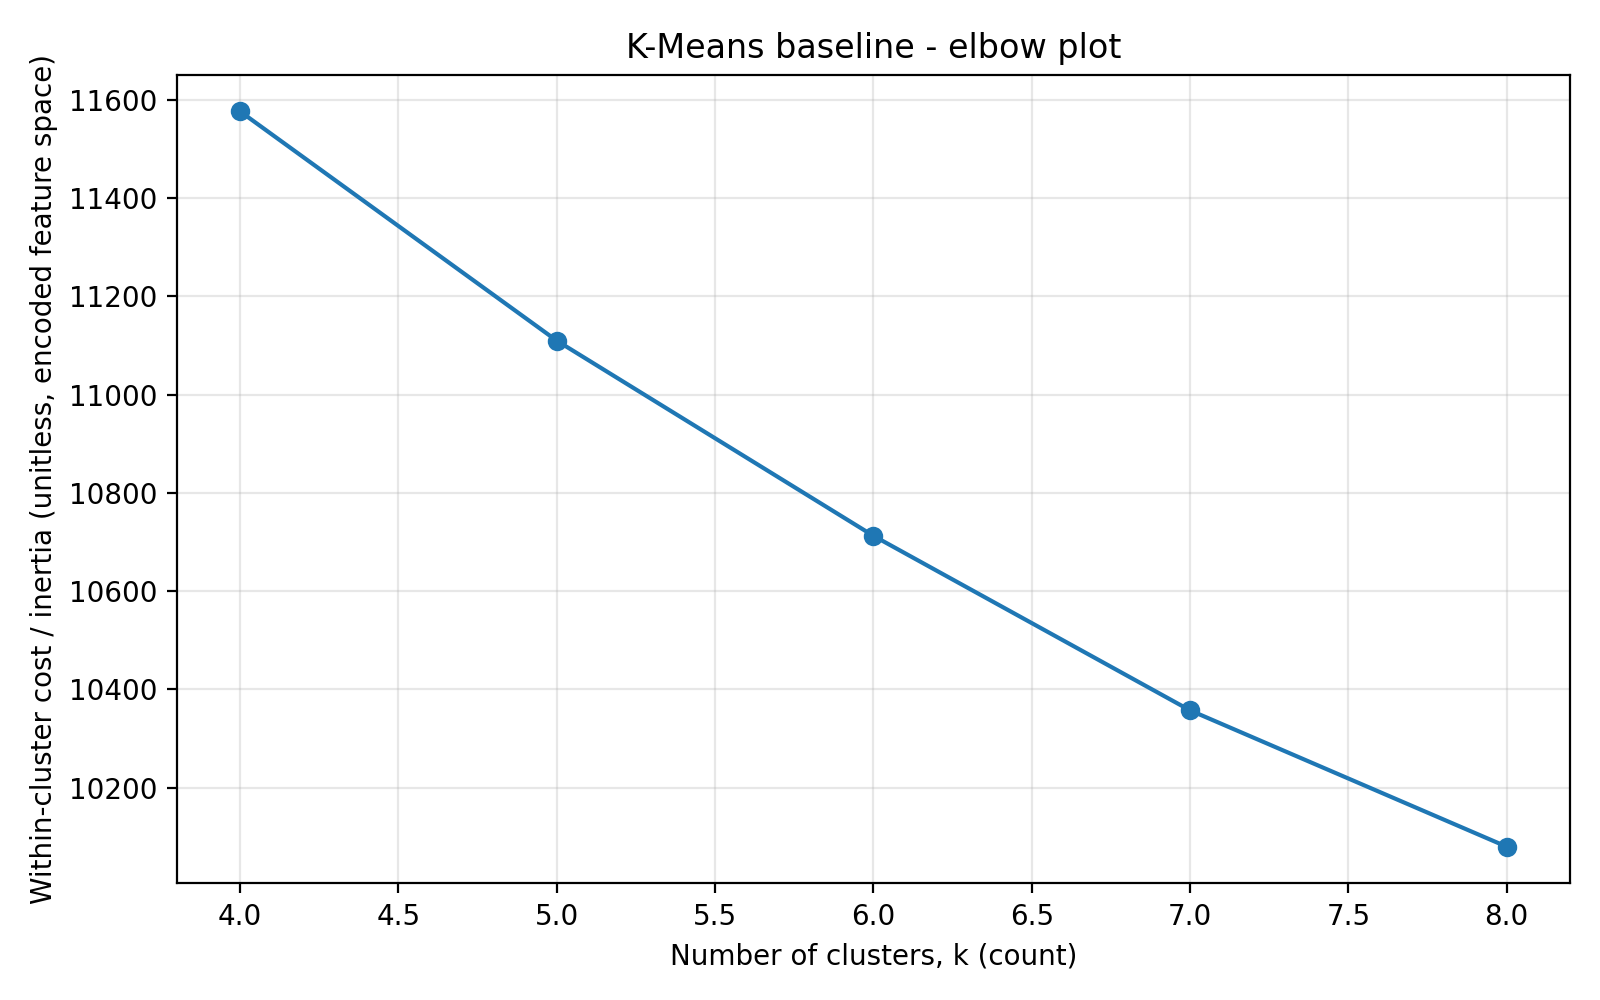

In [69]:
out_path = os.path.join(OUTPUT_DIR, "kmeans_elbow.png")
save_kmeans_elbow_plot(benchmark_df, out_path)
display(Image(filename=out_path))

## 21) Plot: benchmark silhouette comparison

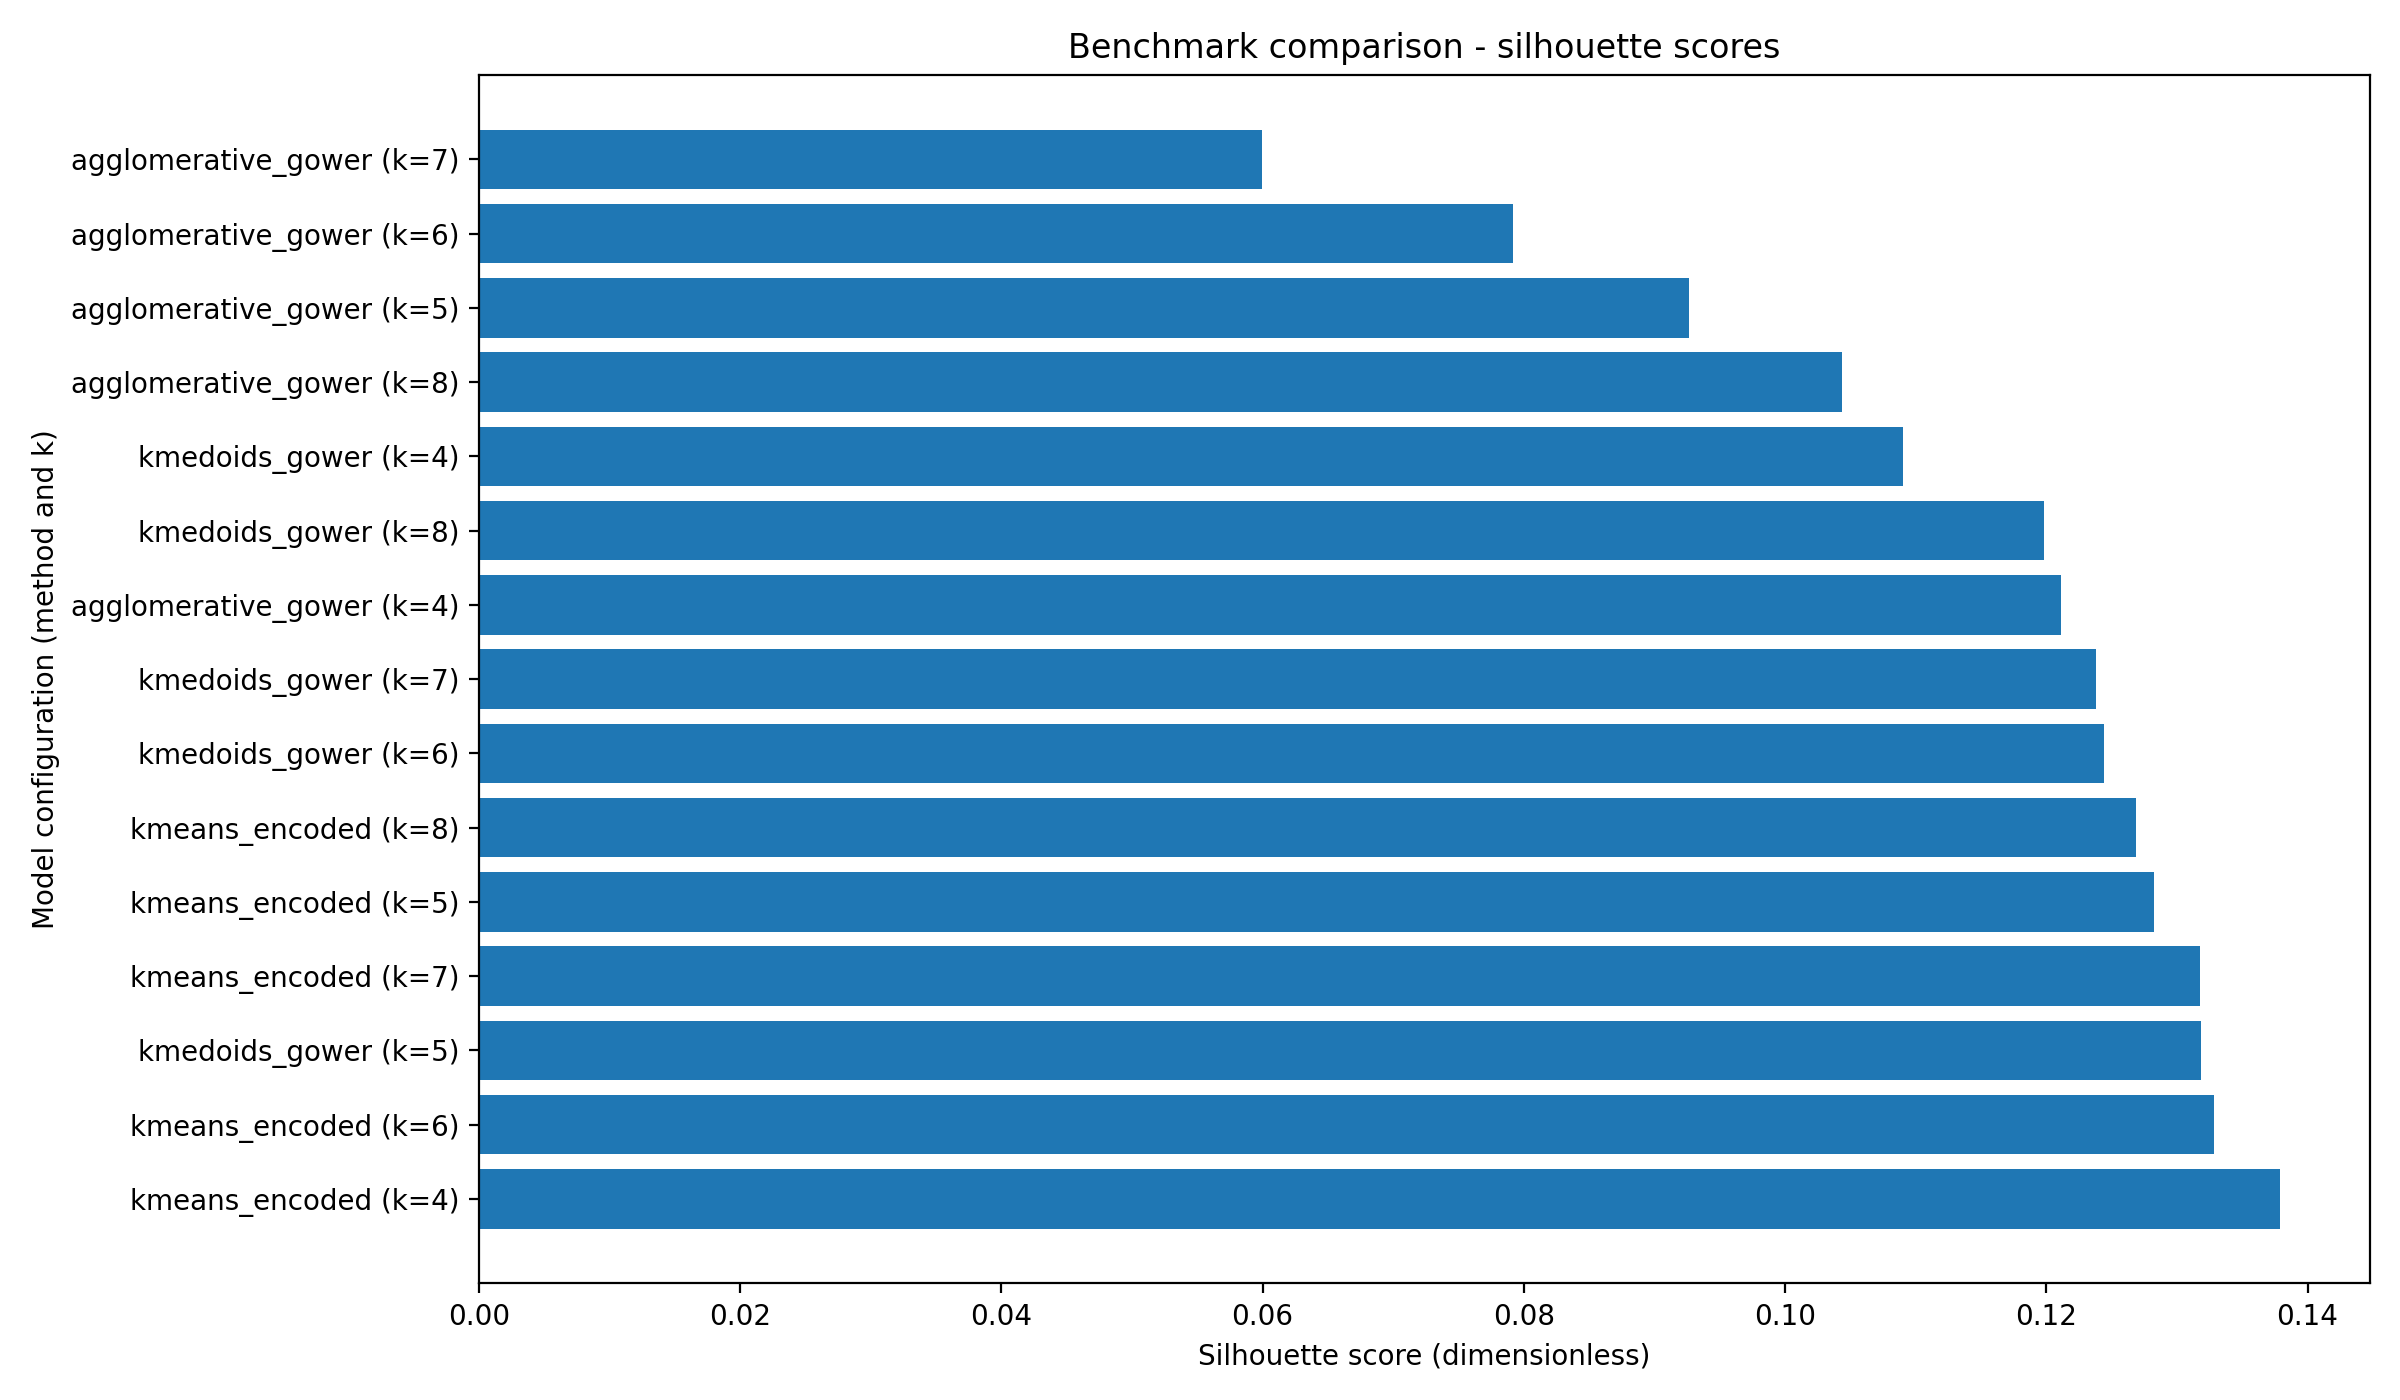

In [70]:
out_path = os.path.join(OUTPUT_DIR, "benchmark_silhouette.png")
save_benchmark_silhouette_plot(benchmark_df, out_path)
display(Image(filename=out_path))

## 22) Plot: DBSCAN KNN curve

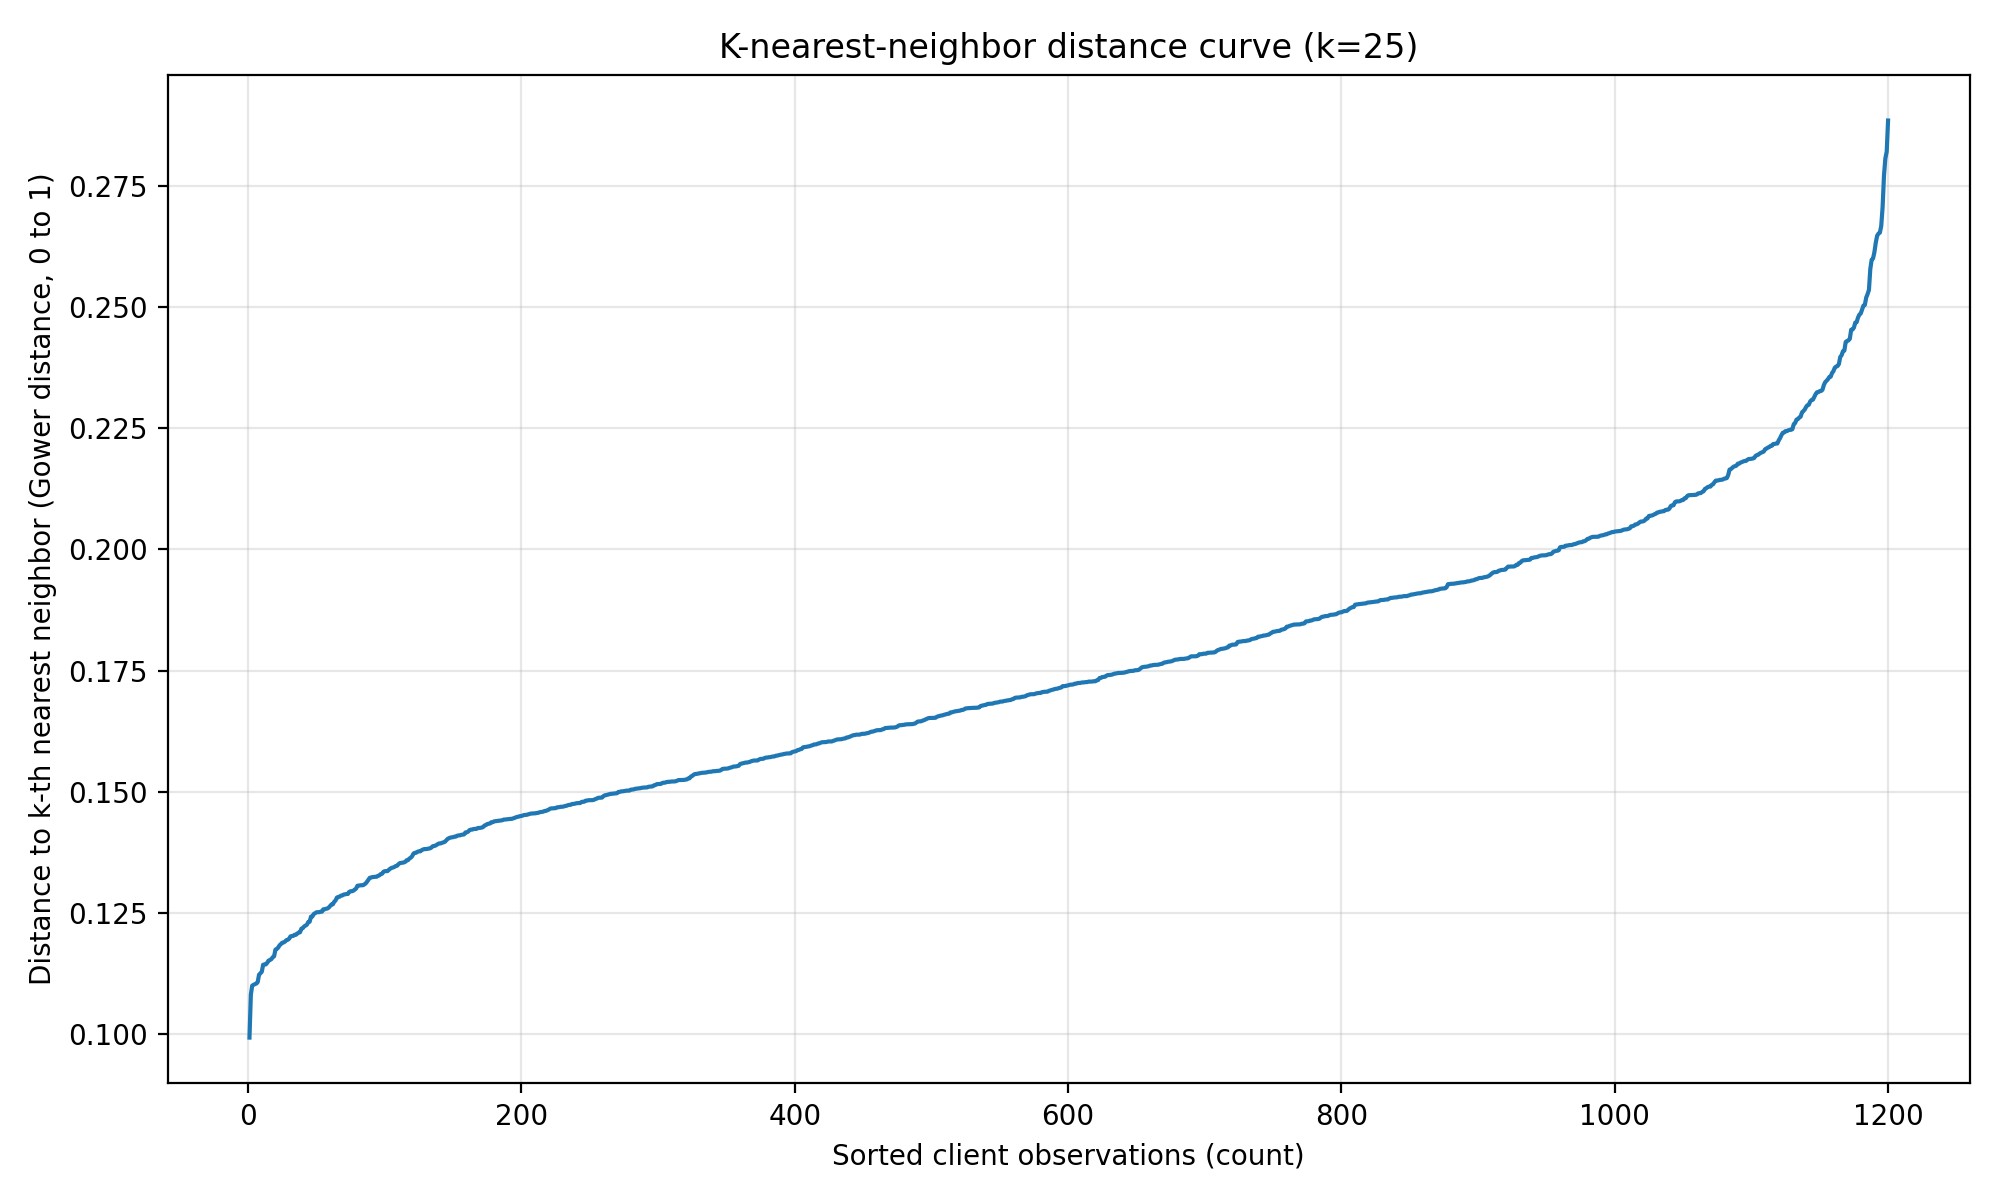

In [71]:
out_path = os.path.join(OUTPUT_DIR, "dbscan_knn_curve.png")
save_dbscan_knn_plot(knn_curve_df, out_path)
display(Image(filename=out_path))

## 23) Plot: cluster sizes

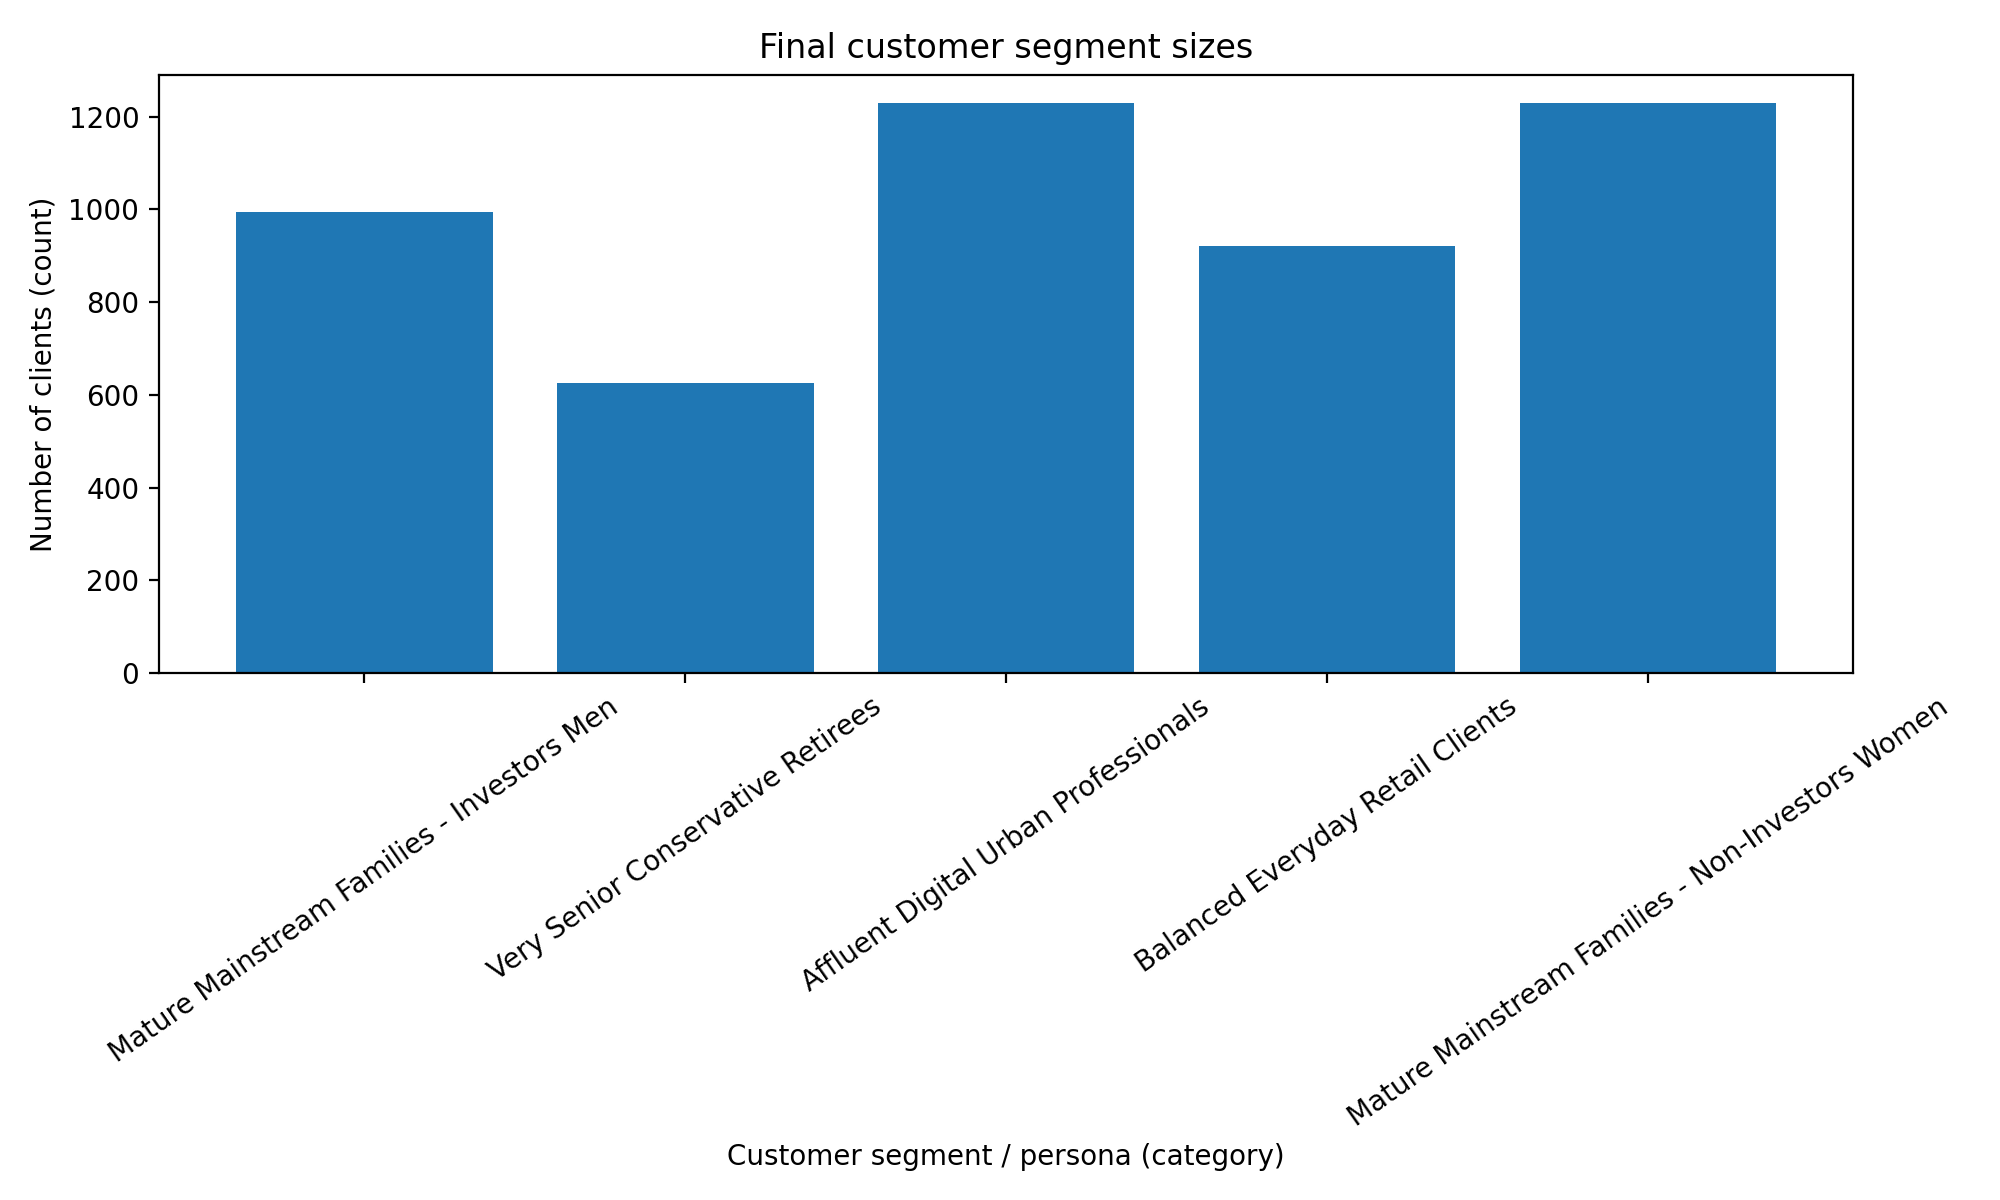

In [72]:
out_path = os.path.join(OUTPUT_DIR, "cluster_sizes.png")
save_cluster_size_plot(profiles, out_path)
display(Image(filename=out_path))

## 24) Plot: PCA scatter of final clusters

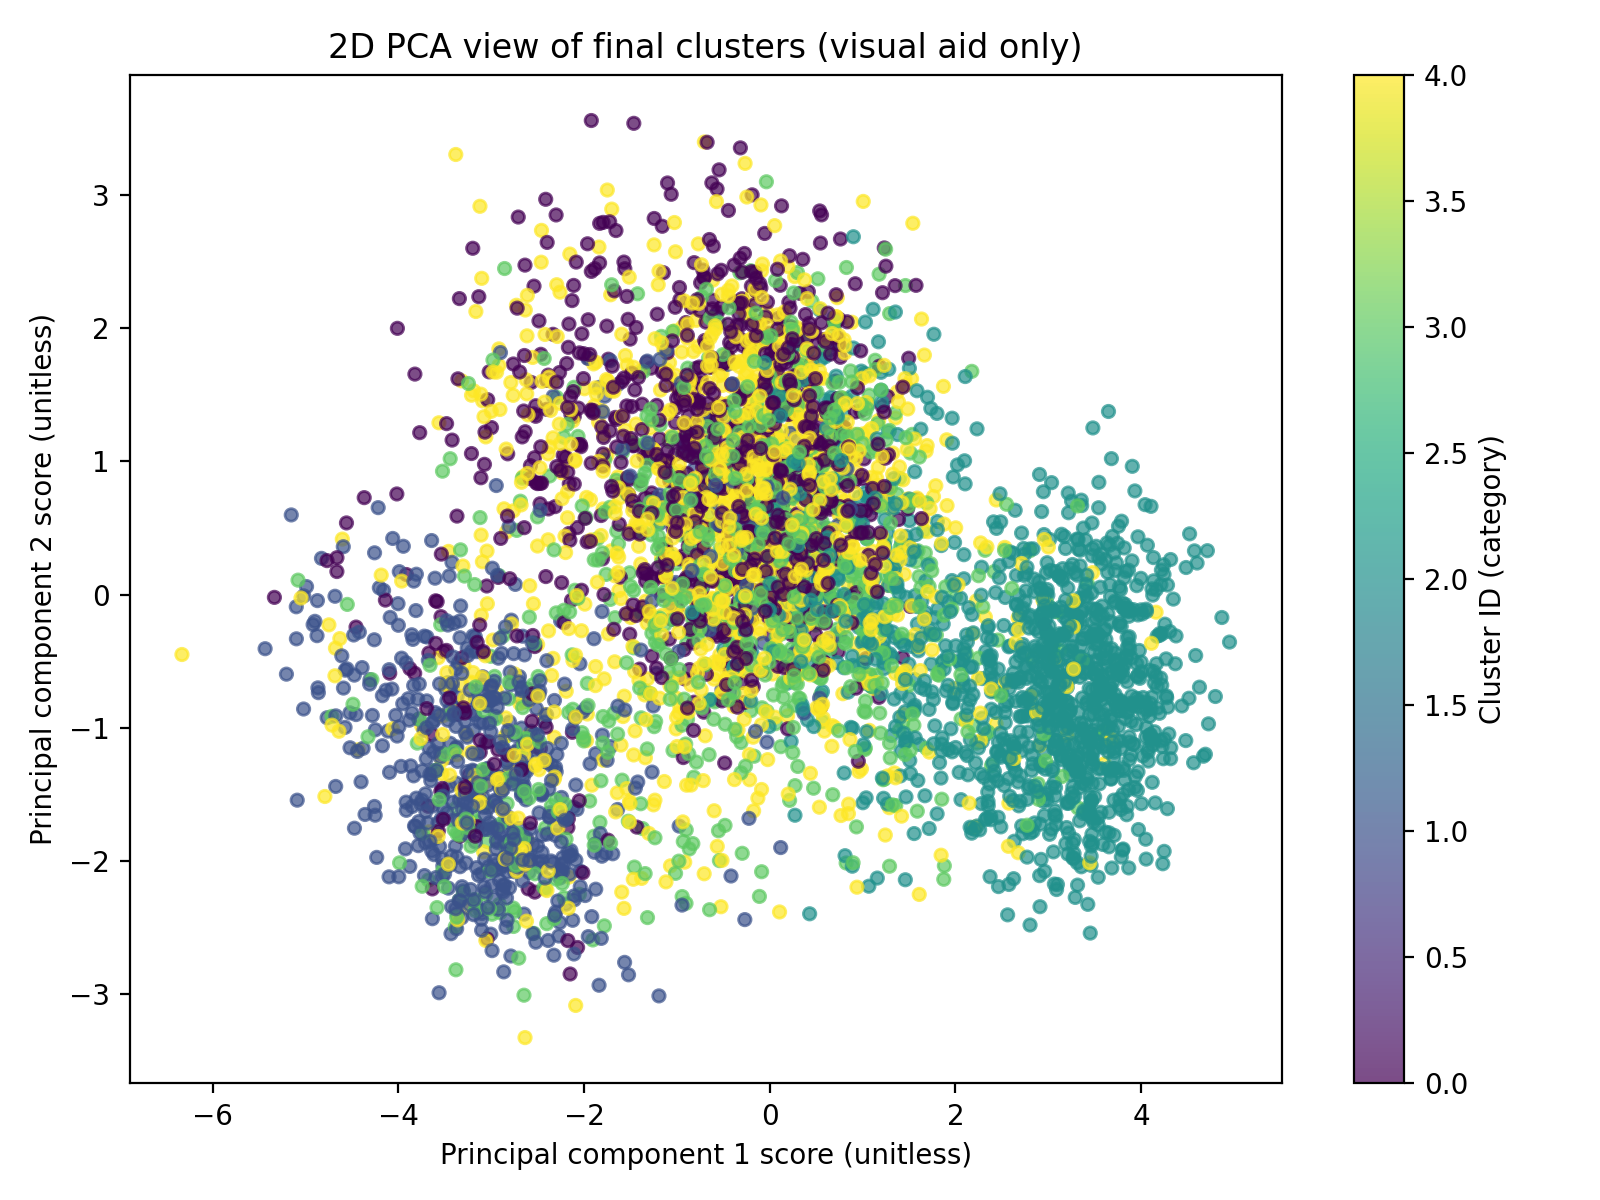

In [73]:
out_path = os.path.join(OUTPUT_DIR, "clusters_pca.png")
save_pca_scatter(segmented_df, numeric_cols, categorical_cols, out_path)
display(Image(filename=out_path))

## 25) Plot: profile heatmap

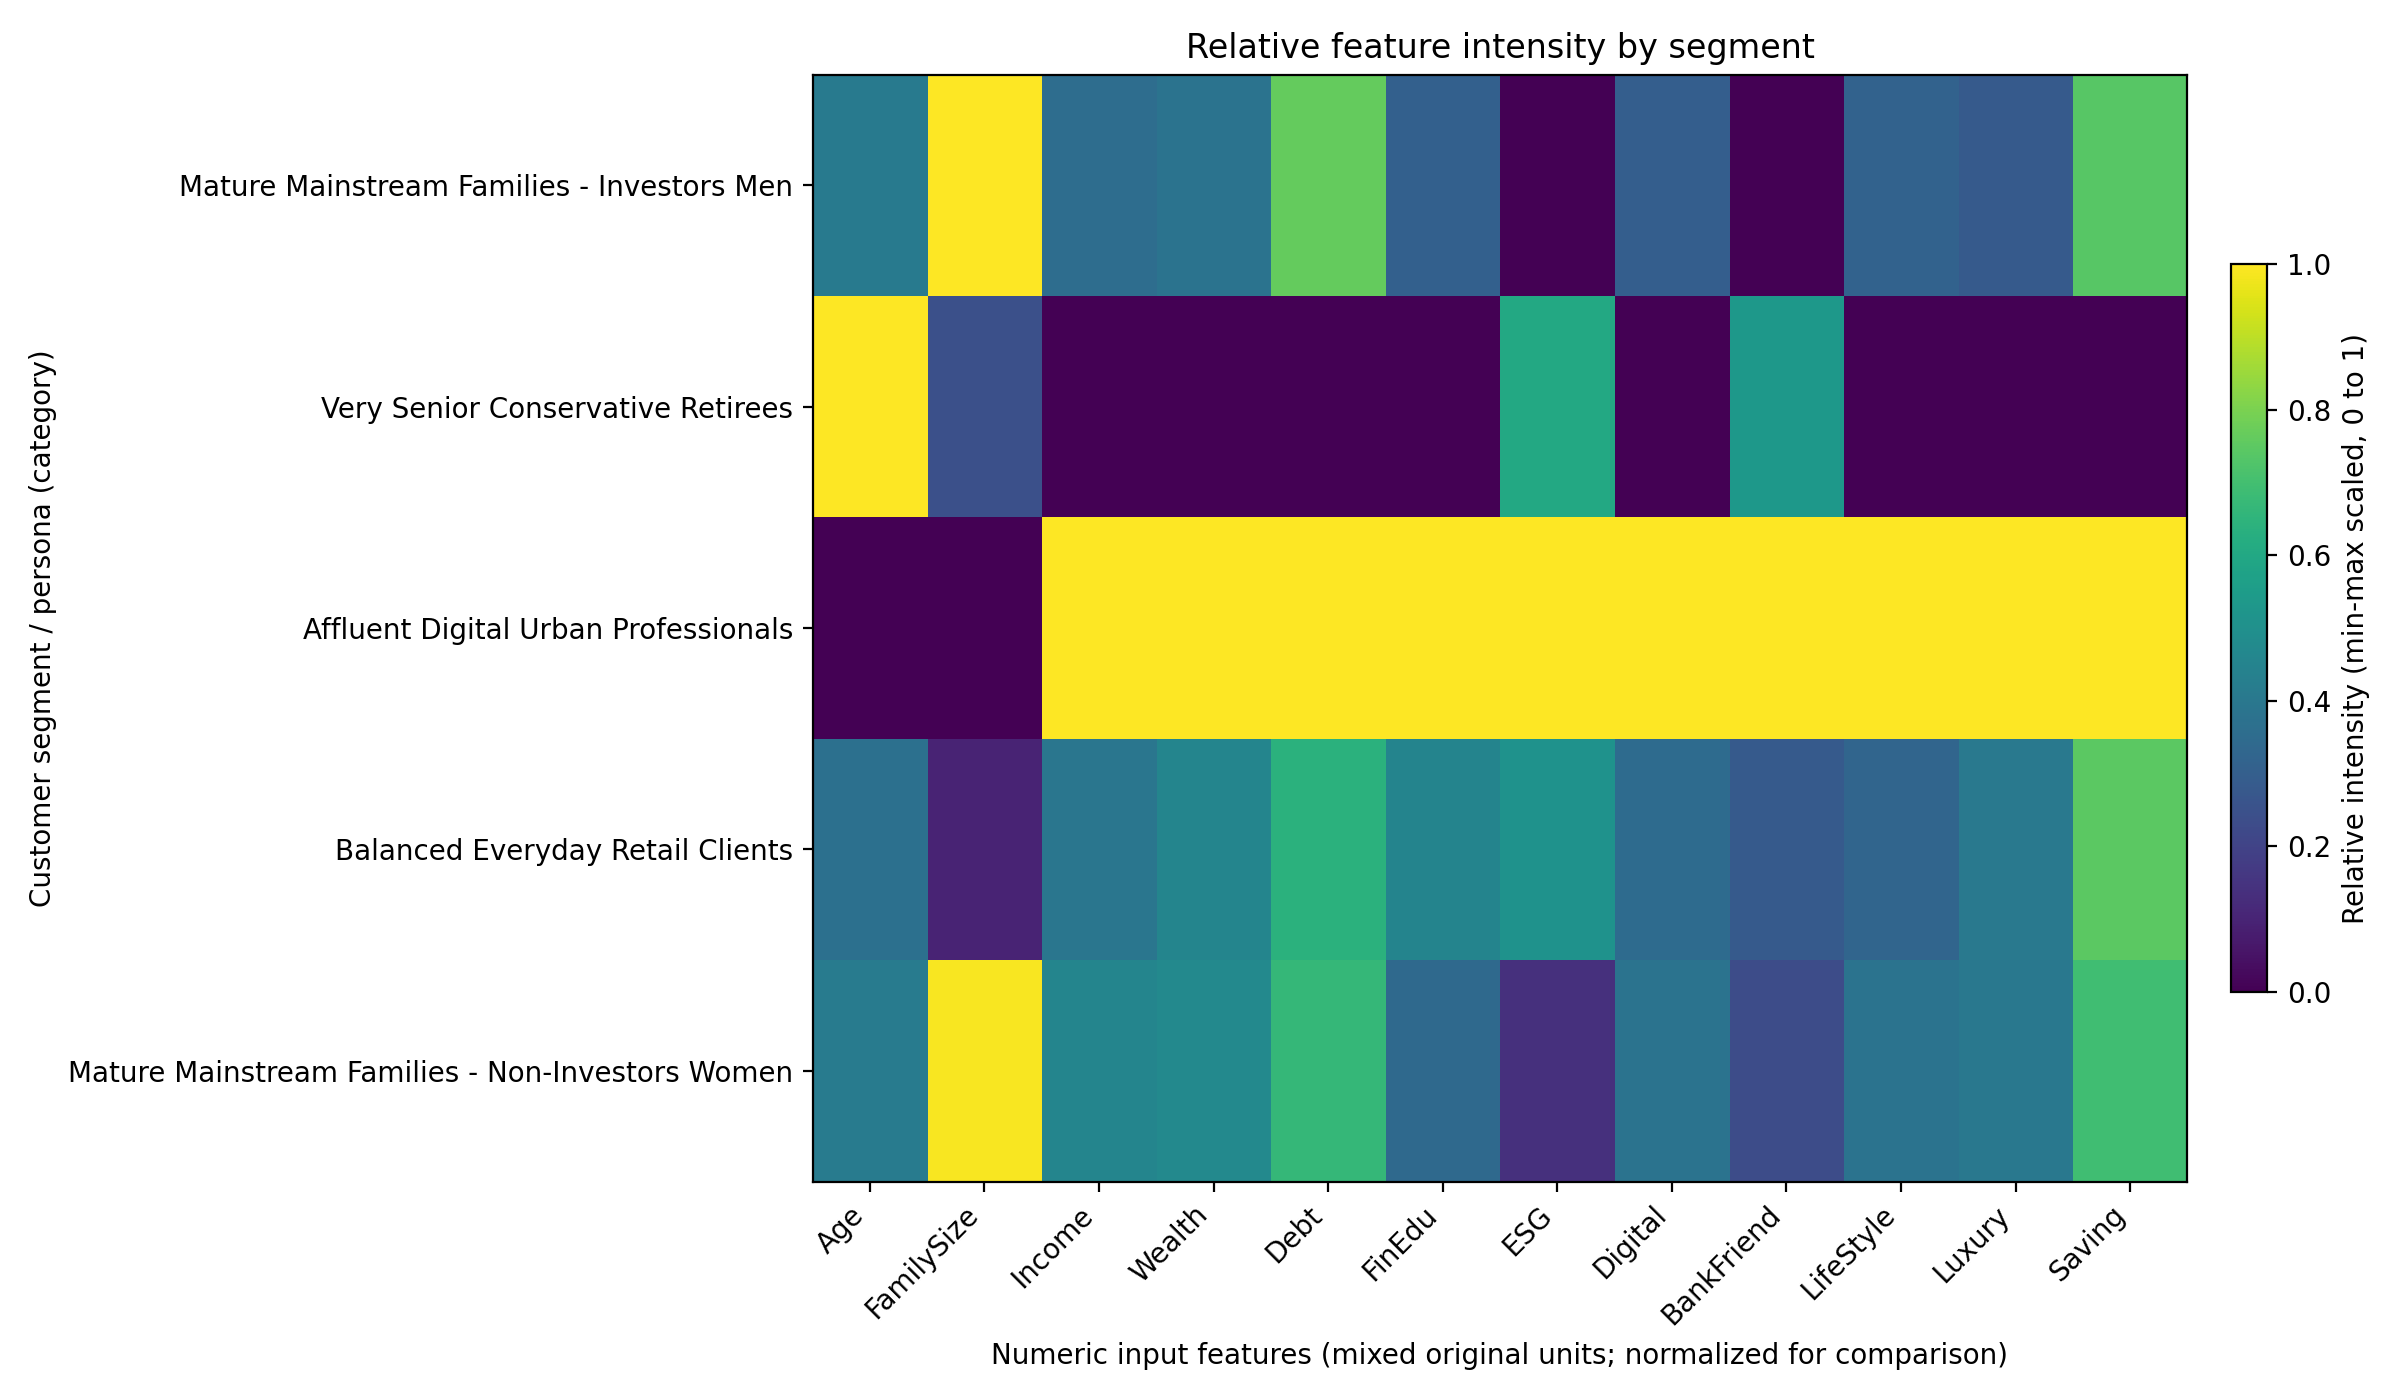

In [74]:
out_path = os.path.join(OUTPUT_DIR, "cluster_profile_heatmap.png")
save_profile_heatmap(profiles, numeric_cols, out_path)
display(Image(filename=out_path))

## 26) Plot: final silhouette sample

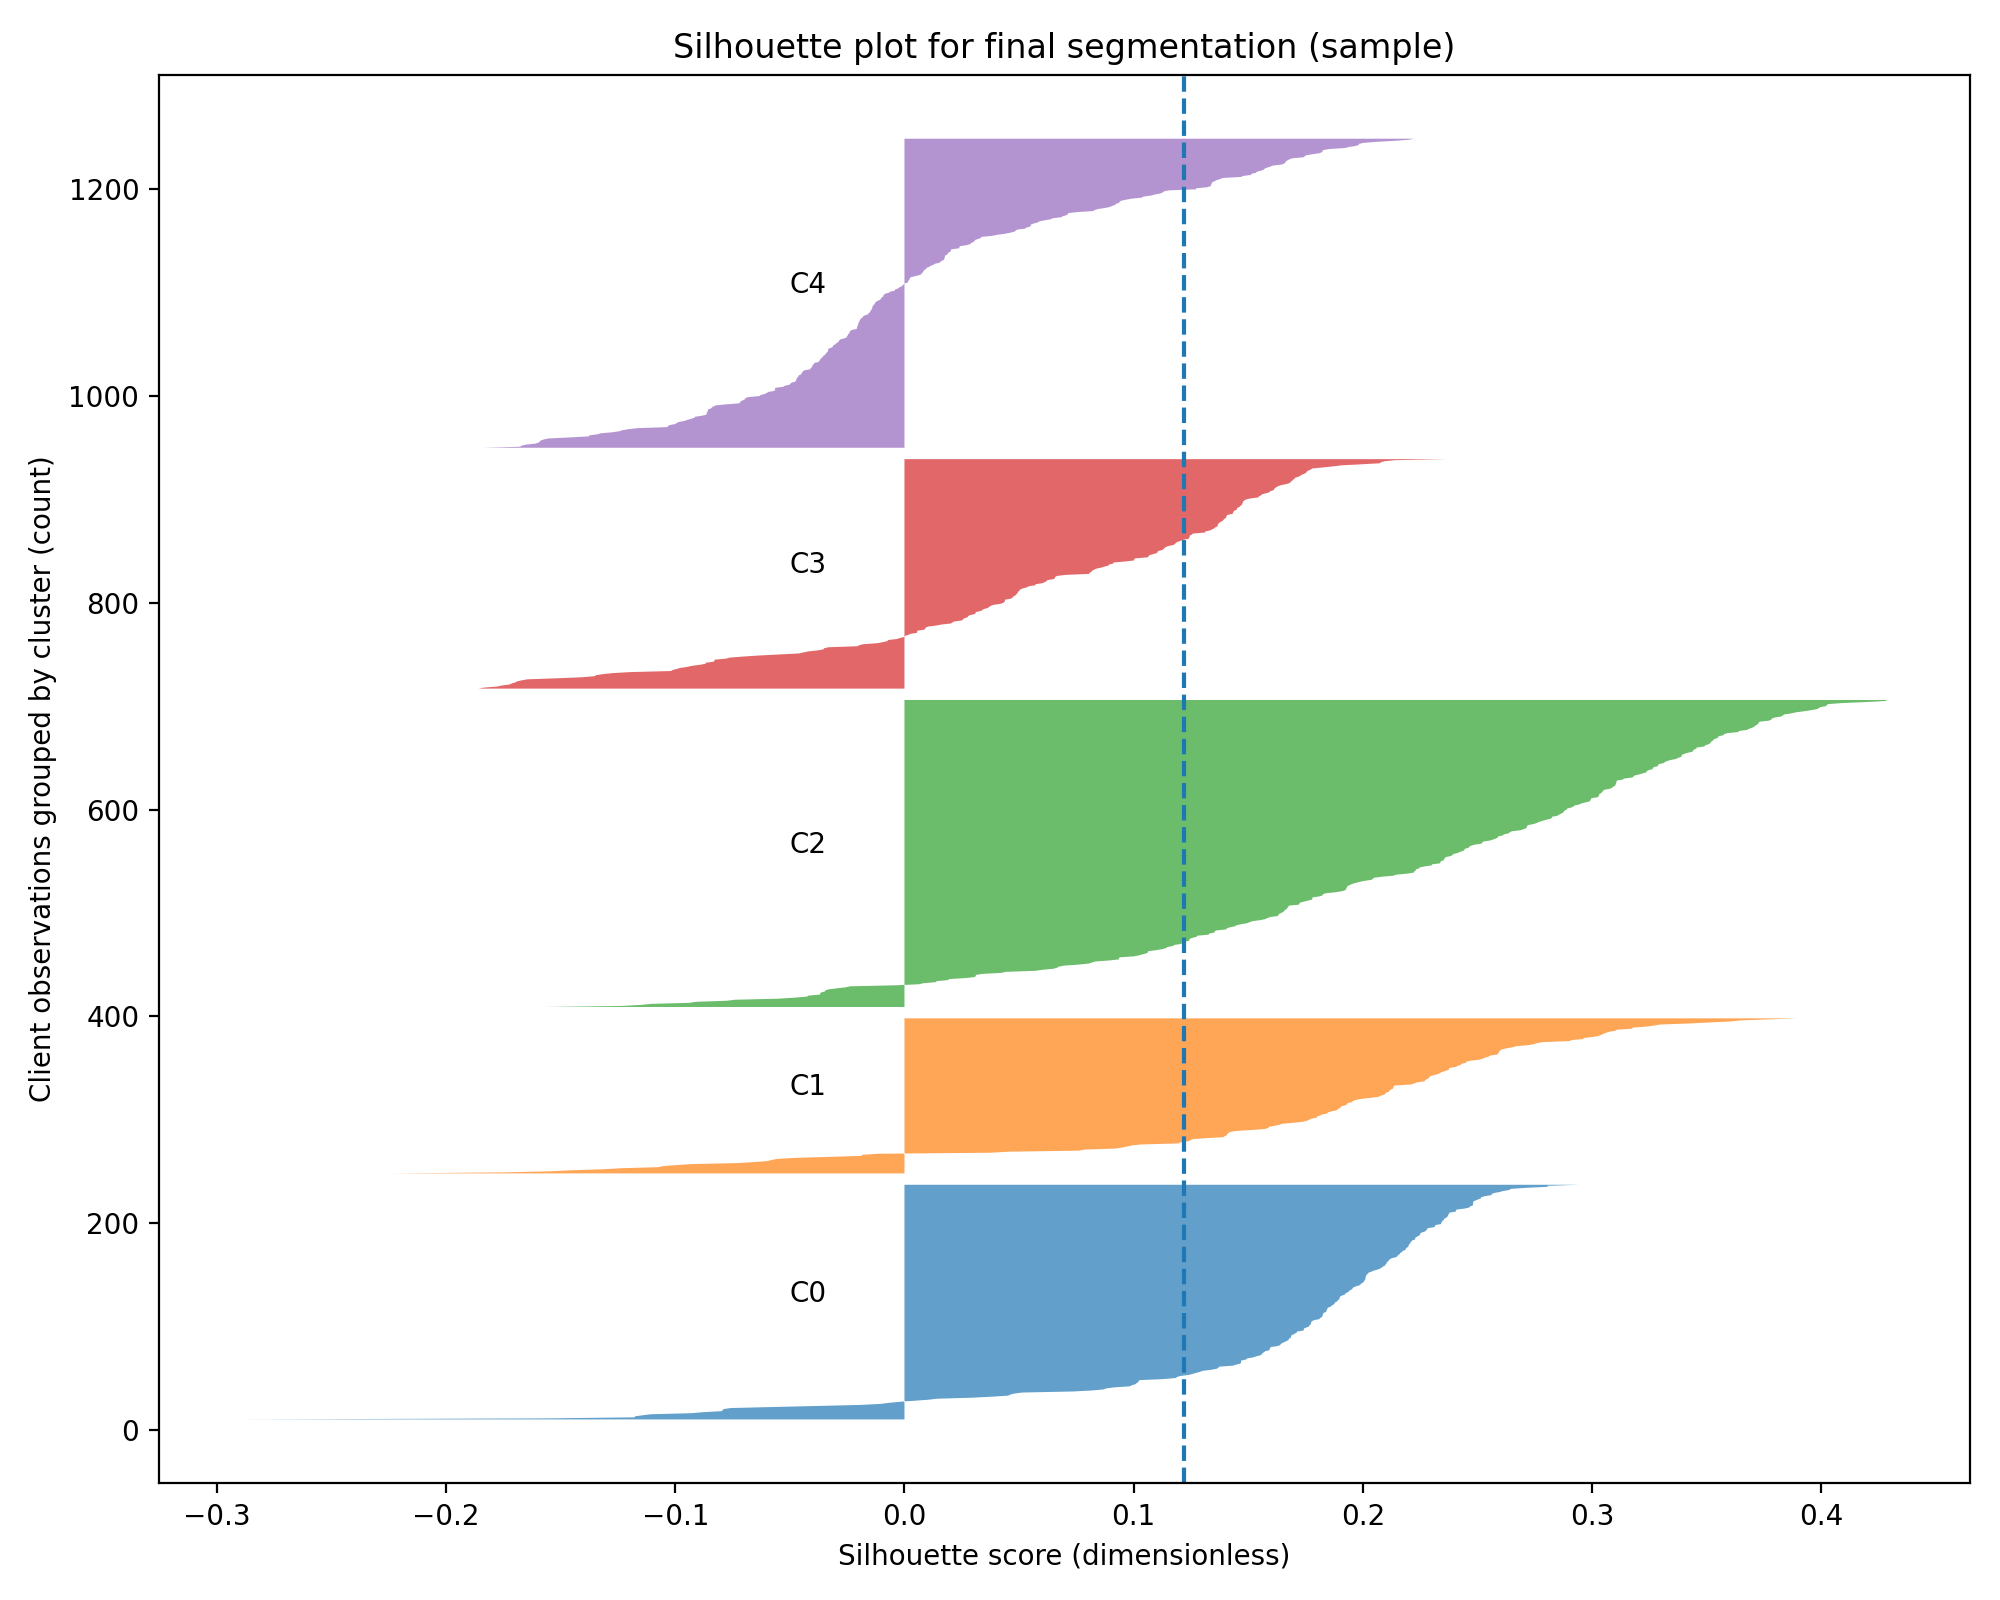

In [75]:
out_path = os.path.join(OUTPUT_DIR, "final_silhouette_sample.png")
save_final_silhouette_plot(D_sample, reference_labels_sample, out_path)
display(Image(filename=out_path))

## 27) Plot: stability across seeds

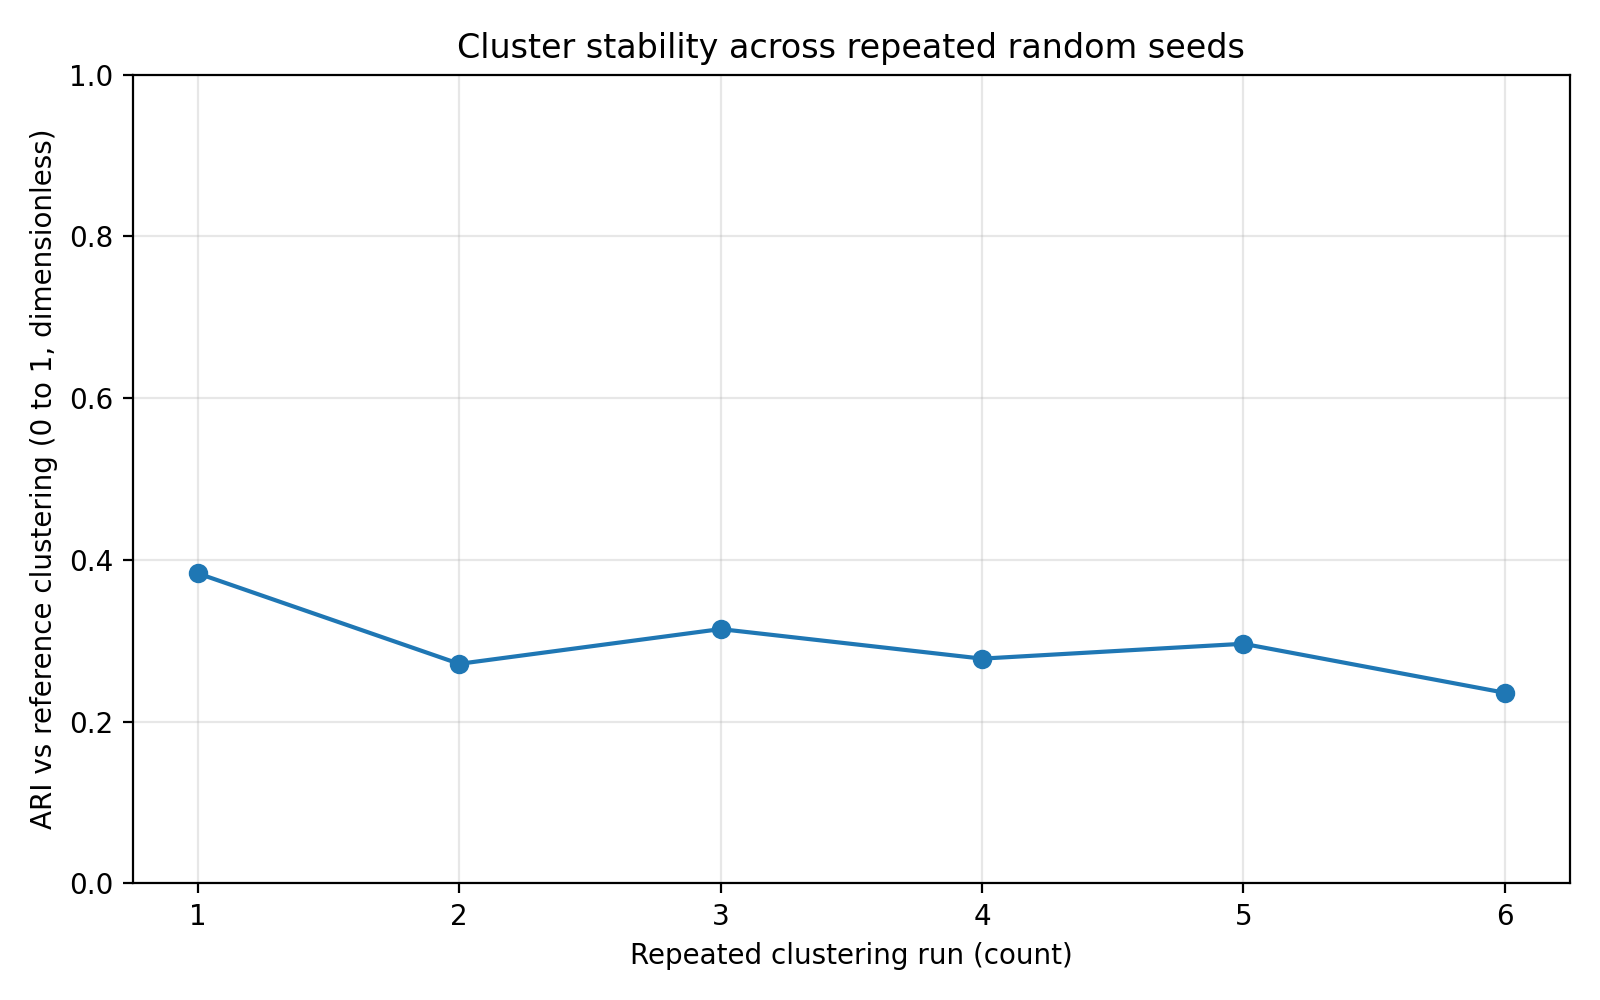

In [76]:
out_path = os.path.join(OUTPUT_DIR, "stability_plot.png")
save_stability_plot(stability_df, out_path)
display(Image(filename=out_path))

## 28) Plot: weight sensitivity

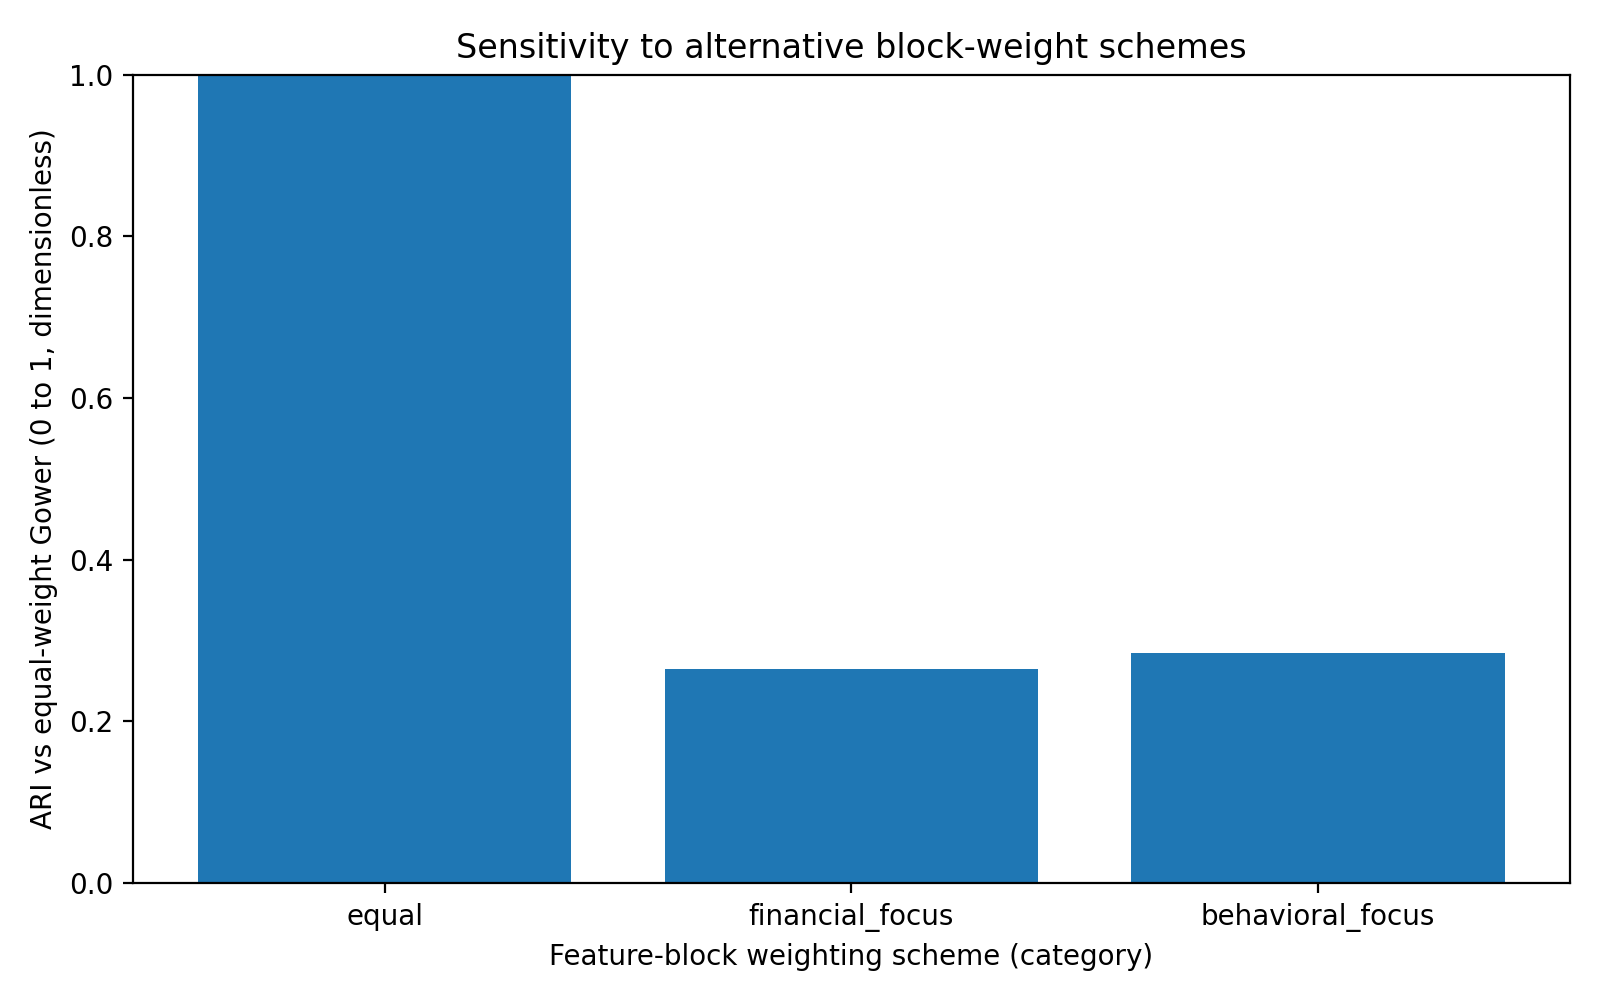

In [77]:
out_path = os.path.join(OUTPUT_DIR, "weight_sensitivity_plot.png")
save_sensitivity_plot(sensitivity_df, out_path)
display(Image(filename=out_path))

## 29) Quick summary

In [78]:
print("=" * 80)
print("UPGRADED CLIENT SEGMENTATION PIPELINE - SUMMARY")
print("=" * 80)
print("Final method: K-Medoids on equal-weight Gower distance")
print(f"Chosen number of segments: {chosen_k}")
print(f"Stability mean ARI: {stability_df['ari_vs_reference'].mean():.3f}")
print(f"Weighted sensitivity mean ARI: {sensitivity_df['ari_vs_equal_gower'].fillna(1.0).mean():.3f}")
print(f"Outputs saved to: {OUTPUT_DIR}")
for name in sorted(os.listdir(OUTPUT_DIR)):
    print(f" - {name}")

UPGRADED CLIENT SEGMENTATION PIPELINE - SUMMARY
Final method: K-Medoids on equal-weight Gower distance
Chosen number of segments: 5
Stability mean ARI: 0.297
Weighted sensitivity mean ARI: 0.516
Outputs saved to: C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1
 - .ipynb_checkpoints
 - AdditionalContentPoliMI.ipynb
 - BankClients_Metadata.xlsx
 - CODE.FINTECH.BC1.ipynb
 - Dataset1_BankClients.xlsx
 - PPT.FINTECH.BC1.pptx
 - SegmentingClientsPoliMI.ipynb
 - Zenti_Business_Case_1.pdf
 - audit_report.txt
 - benchmark_model_comparison.csv
 - benchmark_silhouette.png
 - cluster_medoids.csv
 - cluster_profile_heatmap.png
 - cluster_profiles.csv
 - cluster_sizes.png
 - cluster_stability.csv
 - clusters_pca.png
 - dbscan_knn_curve.csv
 - dbscan_knn_curve.png
 - dbscan_robustness_check.csv
 - final_silhouette_sample.png
 - k_selection_notes.txt
 - kmeans_elbow.png
 - persona_refresh_demo.csv
 - project_explainer.md
 - segmentation_output_pack.xlsx
 - segmented_clients.csv
 - stability_plot